# [drosophila_body_orientation_predictor](https://github.com/nehalsinghmangat/drosophila_body_orientation_predictor) — Data Correction and Model Training

This notebook cleans, corrects, and augments the experimental data from [van Breugel et al. (2014)](https://www.sciencedirect.com/science/article/pii/S0960982213015820) to produce the fully preprocessed dataset used to train the heading predictor neural network.


## Data Correction and Processing

The augmentation and correction pipeline proceeds through the following stages, saving intermediate outputs to `../pipelinedata/`:

1. **`01_merged/`** — Raw Parquet files merged across wind speeds (30/40/60 cm/s)
2. **`02_augmented/`** — Kinematic features added (groundspeed, airspeed, thrust, acceleration)
3. **`03_corrected/`** — 180° heading ambiguities resolved via a single thrust-referenced, weighted, outlier-robust naive correction (`naive_heading_correction_v2`) — no convex optimization, no MOSEK dependency
4. **`04_filtered/`** — Short or uncorrectable trajectories removed
5. **`05_final/`** — Output columns (`heading_angle_x`, `heading_angle_y`) added; ready for model training

There is no separate smoothing stage: `naive_heading_correction_v2` already includes single-frame outlier interpolation, and the corrected trajectories are smooth enough without an additional Savitzky-Golay pass.

Neural network training is handled later in this same notebook.

## Methods


### Data Preparation and Preprocessing

We use data from [van Breugel et al. (2014)](https://doi.org/10.1242/jeb.098665), collected across three constant-wind conditions (30, 40, 60 cm/s). Two data streams are merged per trajectory: (i) flight trajectory (x/y position and velocity) and (ii) body-orientation measurements captured as ellipse parameters. Trajectories shorter than a minimum duration are discarded to ensure adequate temporal context for model training.

Below, we load the raw Parquet files for each wind speed, correct the airspeed reference frame, standardize field names, synchronize timestamps, and merge the two streams into a single CSV per wind speed.

In [ ]:
import os
import sys
import pandas as pd
import datetime

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    correct_for_wind,
    remove_irrelevant_trajectory_data,
    remove_irrelevant_body_data,
    sync_time,
    join_all_body_and_trajec_df,
    transform_timestamps_to_start_at_zero,
)

In [ ]:

windspeeds = ["30cms", "40cms", "60cms"]
for windspeed in windspeeds:
    trajec_df = pd.read_parquet(f"../experimentaldata/{windspeed}/flight_trajectories_3d_HCS_odor_horizon_matched.parquet")
    body_df = pd.read_parquet(f"../experimentaldata/{windspeed}/body_orientations_HCS_odor_horizon_matched.parquet")
    key_table = pd.read_parquet(f"../experimentaldata/{windspeed}/body_trajec_matches.parquet")

    trajec_df = correct_for_wind(trajec_df)
    trajec_df = remove_irrelevant_trajectory_data(trajec_df)
    body_df = remove_irrelevant_body_data(body_df)

    synced_trajectory = sync_time(trajec_df)
    synced_body = sync_time(body_df)

    body_and_trajectory = join_all_body_and_trajec_df(synced_body, synced_trajectory, key_table)
    body_and_trajectory = [transform_timestamps_to_start_at_zero(t) for t in body_and_trajectory]
    body_and_trajectory = [t for t in body_and_trajectory if len(t) > 12]

    temp_fly_data = pd.concat(body_and_trajectory, ignore_index=True)
    os.makedirs(f"../pipelinedata/01_merged/{windspeed}", exist_ok=True)
    temp_fly_data.to_csv(f"../pipelinedata/01_merged/{windspeed}/fly_trajectories_with_body_orientations.csv", index=False)

temp_file_paths = [
    "../pipelinedata/01_merged/30cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/40cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/60cms/fly_trajectories_with_body_orientations.csv",
]
temp_dfs = [pd.read_csv(f) for f in temp_file_paths]
heading_and_trajectories = pd.concat(temp_dfs, ignore_index=True)
heading_and_trajectories.to_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv', index=False)

Visualize the data

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
all_fly_data.head()

#### Kinematic Feature Augmentation

We augment each merged trajectory with physically meaningful derived quantities: groundspeed, airspeed, linear acceleration, and thrust (magnitude and angle). These fields are required both for heading correction (thrust angle serves as a reference direction) and as inputs to the neural network. The heading angle is also initialized here from the ellipse short-axis angle (accurate only modulo π — corrected in the next step).


In [ ]:
import os
import pynumdiff as pynd
import numpy as np

from utils import augment_fly_trajectory

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in all_fly_data.groupby('trajec_objid')]

temp_augmented_all_fly_data = [augment_fly_trajectory(df, compute_heading_from_ellipses=True) for df in body_and_trajectory_by_id]
augmented_all_fly_data = pd.concat(temp_augmented_all_fly_data, ignore_index=True)
os.makedirs('../pipelinedata/02_augmented', exist_ok=True)
augmented_all_fly_data.to_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv', index=False)

#### Body Orientation Correction and Filtering

The body-orientation measurements were captured with a top-down camera. At each frame, the fly was approximated as an ellipse, so the recorded heading is only accurate modulo π. This produces discontinuous π-jumps throughout many trajectories, and measurement noise occasionally corrupts a single frame outright.

We apply one correction step (below) and then filter out any trajectory that still retains an uncorrectable jump.

##### Naïve Heading Correction (thrust-referenced, weighted, outlier-robust)

The body-orientation measurements are only accurate modulo π (the ellipse fit cannot distinguish head from tail), producing discontinuous π-jumps throughout many trajectories. `naive_heading_correction_v2` resolves these in three steps:

1. Aligns the initial heading with the **thrust direction** (not groundspeed direction — thrust stays well-defined even when the fly is nearly stationary and groundspeed direction becomes numerically unstable).
2. Uses `np.unwrap` (period π) to detect and remove π-flips locally, frame by frame.
3. A single-frame outlier in that locally-unwrapped signal — a lone frame that deviates sharply from both neighbors while those neighbors are close to each other, distinguishing an isolated bad measurement from a genuine fast turn — is detected and linearly interpolated.

Both global branch decisions (steps 1 and the final whole-trajectory alignment) use a thrust-magnitude-**weighted** circular mean, so low-thrust (noisier) frames contribute less than high-thrust (more reliable) ones.

This replaces the original naive+convex-optimization two-step correction: the convex-optimization step was found to introduce spurious local jumps and to reject ~1000 otherwise-usable trajectories without a principled reason (MOSEK dependency, and its rejections did not correlate with genuine data quality).

In [ ]:
from utils import naive_heading_correction_v2

##### Visualizing Heading Correction Steps

For troubleshooting and sanity-checking, we visualize a sample of trajectories before and after correction to confirm the algorithm is behaving as expected.

In [ ]:
import os
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
heading_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]

In [ ]:
from utils import plot_trajectory

In [ ]:
import gc

# Loop through EVERY trajectory and create/save figures (no sampling -- for full manual review)
for trajectory in heading_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]

    # Create the subplots with a reduced dpi and adjusted size
    fig, axs = plt.subplots(1, 2, figsize=(8, 10), dpi=100)

    # Plot the original (raw) trajectory
    plot_trajectory(axs[0], trajectory)

    # Apply the corrected heading and plot
    corrected = naive_heading_correction_v2(trajectory.copy())
    plot_trajectory(axs[1], corrected)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/03_corrected/heading_correction_steps_svg', exist_ok=True)
    svg_filename = f'../pipelinedata/03_corrected/heading_correction_steps_svg/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')

    # Close the figure to free up memory
    plt.close(fig)

    # Explicitly call garbage collection to free memory
    gc.collect()

##### Applying Heading Correction to All Trajectories

We apply the correction to every trajectory and save the result.

In [ ]:
import os

augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
body_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]
temp_dfs = []
for traj in body_and_trajectory_by_id:
    corrected_trajec = naive_heading_correction_v2(traj.copy())
    temp_dfs.append(corrected_trajec)
corrected_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)
os.makedirs('../pipelinedata/03_corrected', exist_ok=True)
corrected_aug_all_fly_data.to_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv', index=False)

##### Trajectory Filtering

Some trajectories retain residual π-flips that neither correction step fully resolves. We detect these by computing the circular distance between consecutive heading angles and filtering out trajectories that exceed a threshold jump magnitude.


In [ ]:
from utils import circular_distance, calc_circular_difference

In [ ]:
import os

# Load the CSV file
corrected_aug_all_fly_data = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')

# Group data by 'trajec_objid'
body_and_trajectory_by_id = [group for _, group in corrected_aug_all_fly_data.groupby('trajec_objid')]

# Initialize lists for storing filtered and removed trajectories
temp_dfs = []
temp_bad_dfs = []
removal_count = 0

# Loop through each trajectory and apply filtering based on circular difference
for traj in body_and_trajectory_by_id:
   circ_diff_data = calc_circular_difference(traj)  # Ensure this function returns a DataFrame with 'circ_dist_diff'
   if max(circ_diff_data["circ_dist_diff"]) < (np.pi / 2):  # Filter condition
      temp_dfs.append(traj)  # Keep this trajectory
   else:
      temp_bad_dfs.append(traj)  # Mark this trajectory for removal
      removal_count += 1

# Concatenate the filtered and removed trajectories into separate DataFrames
bad_all_fly_data = pd.concat(temp_bad_dfs, ignore_index=True)
filtered_corr_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)

os.makedirs('../pipelinedata/04_filtered', exist_ok=True)

# Save the filtered data to CSV files
filtered_corr_aug_all_fly_data.to_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv', index=False)

# Save the rejected trajectories
bad_all_fly_data.to_csv('../pipelinedata/04_filtered/rejected_trajectories.csv', index=False)

# Print the total number of trajectories and the number of removals
print(f"Total trajectories: {len(body_and_trajectory_by_id)}")
print(f"Number of removed trajectories: {removal_count}")

##### Visualizing Filtered-Out Trajectories


In [ ]:
import random
import gc

rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]

# Set the random seed for repeatability
random.seed(42)

# Loop through each trajectory and create/save figures
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory, plot_ellipses=False, every_nth=1)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/04_filtered/rejected_trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/04_filtered/rejected_trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

In [ ]:
rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]
bad_trajec_1 = rejected_trajectories.loc[rejected_trajectories["trajec_objid"]=="20121002_184808_1788"]
fig, axs = plt.subplots(1, 3, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],bad_trajec_1)
plot_trajectory(axs[1],bad_trajec_1)
plot_trajectory(axs[2],bad_trajec_1)
plt.show()

##### Visualizing Final Corrected & Filtered Trajectories

In [ ]:
filtered_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')
body_and_trajectory_by_id = [group for _, group in filtered_all_fly_data.groupby('trajec_objid')]

In [ ]:
import random
import gc

# Set the random seed for repeatability
random.seed(42)

# Randomly sample 100 trajectories from heading_and_trajectory_by_id
sampled_trajectories = random.sample(body_and_trajectory_by_id, 100)

# Loop through each trajectory and create/save figures
for trajectory in sampled_trajectories:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/04_filtered/trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/04_filtered/trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

##### Figure 1 Panel A

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import plot_trajectory
augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
filtered_all_fly_data  = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')

test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"] == "20130327_193200_13850"]
corr_trajec = filtered_all_fly_data.loc[filtered_all_fly_data["trajec_objid"] == "20130327_193200_13850"]

fig, axs = plt.subplots(1, 2, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0], test_trajec, heading_color='red', heading_size=0.3,arrow_width=0.010,arrow_scale=0.7)
plot_trajectory(axs[1], corr_trajec, heading_color='red', heading_size=0.3,arrow_width=0.010,arrow_scale=0.7)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_A.svg', format='svg', bbox_inches='tight')
plt.show()

##### Figure 1 Panel B

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import plot_fly_inputs_stacked

augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
panel_b_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"] == "20130327_193200_13850"]

fig, axes = plt.subplots(6, 1, figsize=(10, 8), dpi=150, sharex=True)
plot_fly_inputs_stacked(panel_b_trajec, axes=axes)
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_B.svg', format='svg', bbox_inches='tight')
plt.show()

##### Heading vs. Kinematic Direction (exploratory)

Retained as a supporting exploratory plot; this is no longer Figure 1 Panel C (see below, after Training the Model, for the new Figure 1 Panel C).

In [ ]:
import os, sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import make_color_map

filtered_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')

heading  = filtered_all_fly_data['heading_angle'].values
gs_angle = filtered_all_fly_data['groundspeed_angle'].values
as_angle = filtered_all_fly_data['airspeed_angle'].values

cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)

PI_TICKS  = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
PI_LABELS = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']

def wrap_to_2pi(a):
    return a % (2 * np.pi)

def plot_scatter_heatmap_with_marginals(ax_main, ax_top, ax_right, x_data, y_data,
                                        x_label, y_label, n_bins=128, cmap=None,
                                        show_ylabel=True):
    if cmap is None:
        cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)
    x_data = wrap_to_2pi(x_data)
    y_data = wrap_to_2pi(y_data)
    angle_range = [[0, 2*np.pi], [0, 2*np.pi]]
    h, xedges, yedges = np.histogram2d(x_data, y_data, bins=n_bins, range=angle_range)
    h_masked = np.ma.masked_where(h.T == 0, h.T)
    norm = mcolors.LogNorm(vmin=1, vmax=h.max())
    im = ax_main.pcolormesh(xedges, yedges, h_masked, norm=norm, cmap=cmap)
    ax_main.plot([0, 2*np.pi], [0, 2*np.pi], 'w--', lw=0.6, alpha=0.4)
    ax_main.set_xlim(0, 2*np.pi)
    ax_main.set_ylim(0, 2*np.pi)
    ax_main.set_xticks(PI_TICKS)
    ax_main.set_xticklabels(PI_LABELS)
    ax_main.set_yticks(PI_TICKS)
    ax_main.set_yticklabels(PI_LABELS if show_ylabel else ['']*len(PI_TICKS))
    ax_main.set_xlabel(x_label, fontsize=10)
    if show_ylabel:
        ax_main.set_ylabel(y_label, fontsize=10)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    x_counts, x_bin_edges = np.histogram(x_data, bins=n_bins, range=(0, 2*np.pi))
    x_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
    ax_top.fill_between(x_centers, x_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_top.set_xlim(0, 2*np.pi)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    for spine in ax_top.spines.values():
        spine.set_visible(False)
    y_counts, y_bin_edges = np.histogram(y_data, bins=n_bins, range=(0, 2*np.pi))
    y_centers = 0.5 * (y_bin_edges[:-1] + y_bin_edges[1:])
    ax_right.fill_betweenx(y_centers, y_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_right.set_ylim(0, 2*np.pi)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    for spine in ax_right.spines.values():
        spine.set_visible(False)
    return im

fig = plt.figure(figsize=(11, 5))
outer = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1, width_ratios=[10, 10, 0.4])

gs1 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax1_top   = fig.add_subplot(gs1[0, 0])
ax1_main  = fig.add_subplot(gs1[1, 0])
ax1_right = fig.add_subplot(gs1[1, 1])
fig.add_subplot(gs1[0, 1]).axis('off')

gs2 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax2_top   = fig.add_subplot(gs2[0, 0])
ax2_main  = fig.add_subplot(gs2[1, 0])
ax2_right = fig.add_subplot(gs2[1, 1])
fig.add_subplot(gs2[0, 1]).axis('off')

gs_cbar = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[2],
    height_ratios=[1, 4], hspace=0.05)
ax_cbar = fig.add_subplot(gs_cbar[1, 0])

im1 = plot_scatter_heatmap_with_marginals(
    ax1_main, ax1_top, ax1_right,
    gs_angle, heading, 'Groundspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=True)
im2 = plot_scatter_heatmap_with_marginals(
    ax2_main, ax2_top, ax2_right,
    as_angle, heading, 'Airspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=False)

cbar = fig.colorbar(im2, cax=ax_cbar, label='Count (log scale)')
cbar.ax.yaxis.label.set_size(10)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/heading_vs_kinematic_direction.svg', format='svg', bbox_inches='tight')
plt.show()

### Feature Augmentation, Rotation Augmentation, and Delay Embedding

To construct inputs for the neural network, we augment the processed trajectories with a time-delay embedding of six kinematic variables: groundspeed, groundspeed angle, airspeed, airspeed angle, thrust, and thrust angle. A backward-looking window of $W = 4$ timesteps yields $6 \times 4 = 24$ input features per training example. The target output is the heading direction represented as $(\cos\theta_t, \sin\theta_t)$, stored as `heading_angle_x` and `heading_angle_y`.

Note: rotation augmentation (randomly rotating all angular quantities per trajectory to remove wind-direction bias) was applied in the CEM model variant (`model_CEM_all-angle-rotate.keras`) but is not included in the base model trained here.


#### Import Preprocessed Data

Import the fully preprocessed dataset (corrected, filtered) and add the `heading_angle_x`/`heading_angle_y` output columns. There is no separate smoothing stage — `naive_heading_correction_v2` already includes outlier interpolation, and the filtered trajectories are used directly.

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

final_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')
final_all_fly_data['heading_angle_x'] = np.cos(final_all_fly_data['heading_angle'])
final_all_fly_data['heading_angle_y'] = np.sin(final_all_fly_data['heading_angle'])
os.makedirs('../pipelinedata/05_final', exist_ok=True)
final_all_fly_data.to_csv('../pipelinedata/05_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv', index=False)

## Model Training


### Motivating an ANN

Before training a neural network, it is worth asking whether a much simpler model already
solves the problem. We fit ordinary least-squares (OLS) baselines directly on the three
physical kinematic quantities available at each frame — thrust, airspeed, and groundspeed —
individually and in combination, in two forms:

- **linear** — regress `heading_angle_x`/`heading_angle_y` on the raw Cartesian components
  of each quantity (e.g. `thrust * cos(thrust_angle)`, `thrust * sin(thrust_angle)`), so
  both magnitude and direction enter linearly.
- **circular** — regress the same two targets on only the unit-direction of each quantity
  (`cos(angle)`, `sin(angle)`), discarding magnitude entirely (the standard degree-1
  trigonometric-polynomial formulation for circular-circular regression).

All models are fit on a trajectory-grouped training split (no trajectory contributes frames
to both train and test) and evaluated on the same held-out test trajectories, split further
by flight-direction regime (upwind / crosswind / downwind, classified from the true heading
relative to the wind axis).

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import GroupShuffleSplit

from utils import circular_distance

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

final_all_fly_data = pd.read_csv('../pipelinedata/05_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv')
print(f"{len(final_all_fly_data)} frames, {final_all_fly_data['trajec_objid'].nunique()} trajectories")

# Trajectory-grouped train/test split -- no trajectory appears on both sides
traj_ids = final_all_fly_data['trajec_objid'].unique()
gss = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_SEED)
dummy_X = np.zeros((len(traj_ids), 1))
train_idx, test_idx = next(gss.split(dummy_X, groups=traj_ids))
train_ids = set(traj_ids[train_idx])
test_ids = set(traj_ids[test_idx])
train_df = final_all_fly_data[final_all_fly_data['trajec_objid'].isin(train_ids)].reset_index(drop=True)
test_df = final_all_fly_data[final_all_fly_data['trajec_objid'].isin(test_ids)].reset_index(drop=True)
print(f"Train: {len(train_df)} frames ({len(train_ids)} trajectories)")
print(f"Test:  {len(test_df)} frames ({len(test_ids)} trajectories)")

113738 frames, 3336 trajectories
Train: 76304 frames (2235 trajectories)
Test:  37434 frames (1101 trajectories)


In [2]:
quantities = {
    'thrust': ('thrust', 'thrust_angle'),
    'air': ('airspeed', 'airspeed_angle'),
    'ground': ('groundspeed', 'groundspeed_angle'),
}


def design_matrix(d, combo, kind):
    cols, names = [], []
    for q in combo:
        mag_col, ang_col = quantities[q]
        if kind == 'linear':
            cols += [d[mag_col].values * np.cos(d[ang_col].values),
                      d[mag_col].values * np.sin(d[ang_col].values)]
            names += [f'{q}_x', f'{q}_y']
        else:  # circular
            cols += [np.cos(d[ang_col].values), np.sin(d[ang_col].values)]
            names += [f'{q}_cos', f'{q}_sin']
    return pd.DataFrame(np.column_stack(cols), columns=names)


def fit_ols_baseline(train_d, test_d, combo, kind):
    Xtr = sm.add_constant(design_matrix(train_d, combo, kind))
    Xte = sm.add_constant(design_matrix(test_d, combo, kind), has_constant='add')
    model_x = sm.OLS(train_d['heading_angle_x'].values, Xtr).fit()
    model_y = sm.OLS(train_d['heading_angle_y'].values, Xtr).fit()
    pred_xy = np.column_stack([model_x.predict(Xte), model_y.predict(Xte)])
    return pred_xy


def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def classify_direction(angle_rad):
    # Project convention: positive x = upwind, wind heading = negative x direction.
    deg = np.degrees(np.arctan2(np.sin(angle_rad), np.cos(angle_rad)))
    return np.where(
        np.abs(deg) <= 45, 'upwind',
        np.where(np.abs(np.abs(deg) - 180) <= 45, 'downwind', 'crosswind')
    )


regime = classify_direction(test_df['heading_angle'].values)
y_true = test_df[['heading_angle_x', 'heading_angle_y']].values

combos = [c for r in range(1, 4) for c in combinations(quantities.keys(), r)]
rows = []
for combo in combos:
    combo_label = '+'.join(combo)
    for kind in ['linear', 'circular']:
        pred_xy = fit_ols_baseline(train_df, test_df, combo, kind)
        err = angular_error_deg(y_true, pred_xy)
        per_frame = pd.DataFrame({'trajec_objid': test_df['trajec_objid'].values, 'err': err, 'regime': regime})
        per_traj_regime = per_frame.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
        overall_per_traj = per_frame.groupby('trajec_objid')['err'].median()
        row = {'model': f'{kind}: {combo_label}', 'overall': overall_per_traj.median()}
        for reg in ['upwind', 'crosswind', 'downwind']:
            row[reg] = per_traj_regime.loc[per_traj_regime['regime'] == reg, 'err'].median()
        rows.append(row)

ols_regime_table = pd.DataFrame(rows).sort_values('overall').reset_index(drop=True)
pd.set_option('display.width', 140)
print(ols_regime_table.to_string(index=False))
os.makedirs('../pipelinedata/05_final', exist_ok=True)
ols_regime_table.to_csv('../pipelinedata/05_final/ols_baselines_by_regime.csv', index=False)

                      model   overall     upwind  crosswind  downwind
         linear: thrust+air  9.914509  55.753323  33.742061  5.578776
  linear: thrust+air+ground  9.952172  48.870788  33.464239  5.294615
      linear: thrust+ground  9.988820  50.771355  33.929740  5.140940
circular: thrust+air+ground 10.183422  34.619504  33.849435  6.474696
       circular: air+ground 10.557251  35.292066  37.548600  6.515436
              circular: air 10.572634  46.053448  44.665688  6.409555
       circular: thrust+air 10.848567  45.874091  39.807893  7.127760
                linear: air 10.944150  56.296589  35.653003  5.629149
         linear: air+ground 11.068469  53.347126  35.493400  5.396579
             linear: ground 11.219829  60.357592  37.422769  5.498748
    circular: thrust+ground 12.713324  43.536761  38.337269  7.307998
           circular: ground 16.737941 112.474782  40.705507  7.740805
           circular: thrust 18.058905  64.203191  54.874552 11.413702
             linear:

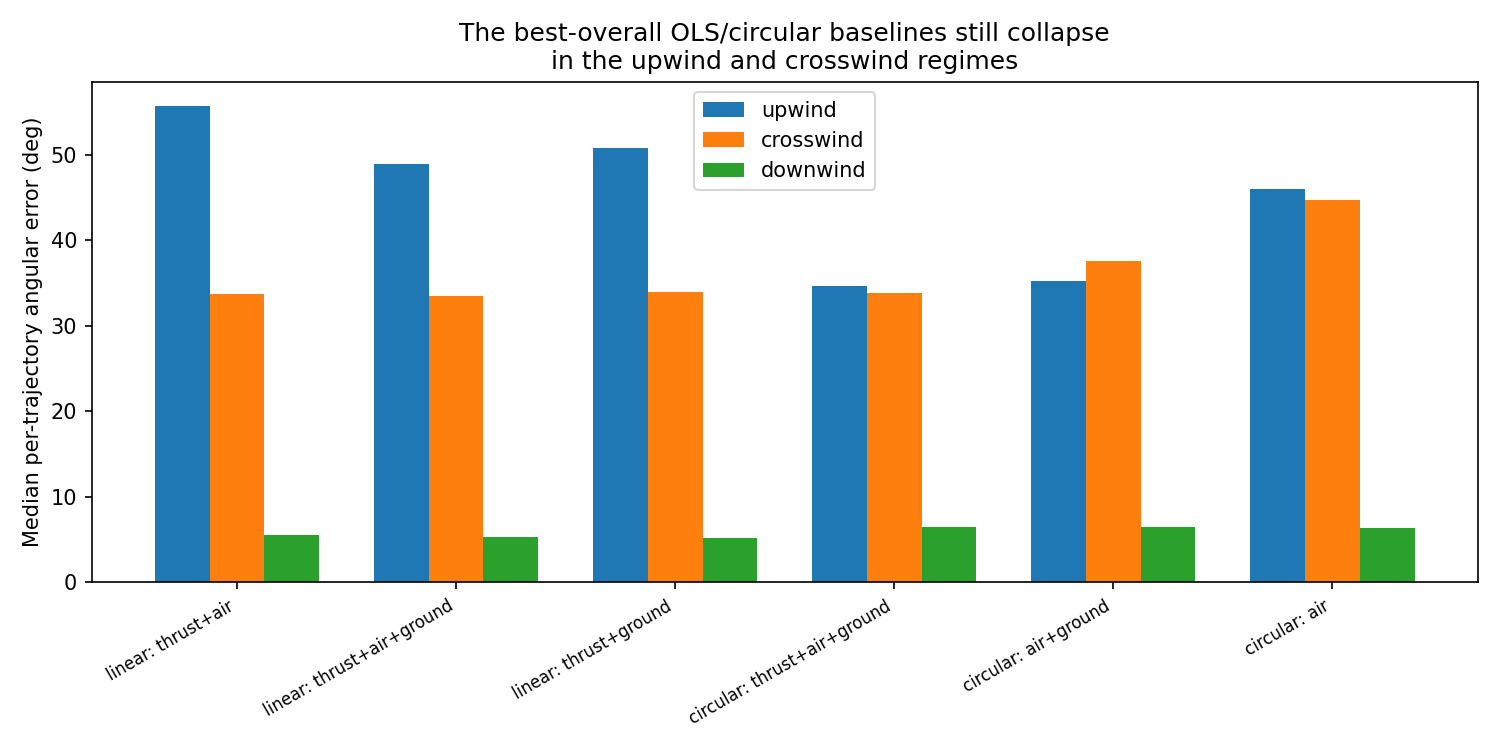

In [3]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
plot_models = ols_regime_table['model'].tolist()[:6]  # the 6 best-overall baselines
x = np.arange(len(plot_models))
width = 0.25

for i, regime_name in enumerate(['upwind', 'crosswind', 'downwind']):
    values = ols_regime_table.set_index('model').loc[plot_models, regime_name].values
    ax.bar(x + (i - 1) * width, values, width, label=regime_name)

ax.set_xticks(x)
ax.set_xticklabels(plot_models, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('The best-overall OLS/circular baselines still collapse\nin the upwind and crosswind regimes')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/motivating_ann_ols_by_regime.svg', format='svg')
plt.show()

**Significance:** Every OLS/circular baseline collapses in the upwind and crosswind regimes even when its POOLED error looks reasonable. The best overall baseline (linear thrust+air, 9.91 deg pooled) reaches 55.75 deg upwind and 33.74 deg crosswind, vs. just 5.58 deg downwind - a roughly 10x spread depending purely on which direction the fly happens to be heading. This is not a fluke of one baseline: every one of the 14 fits shows the same qualitative pattern, including the best circular fit (thrust+air+ground, 34.6 deg upwind / 33.8 deg crosswind / 6.5 deg downwind) and the worst (linear thrust alone, 115 deg upwind).

The mechanism is the same one identified when auditing this pipeline's regime-dependent difficulty more broadly: downwind is the regime where groundspeed magnitude is largest (a tailwind adds to the fly's forward airspeed), making groundspeed *direction* numerically well-determined; upwind and crosswind are where groundspeed can be small or dominated by drift, making its direction - and the OLS predictions built from it - unstable. No single fixed linear (or circular) combination of these three kinematic quantities can adapt its behavior to the regime it happens to be in.

This is the direct motivation for a neural network: a model with enough flexibility to learn a *different* effective mapping in each regime, rather than being forced to average across all of them with one fixed set of coefficients.

### Training the Model

We train the ANN on the same trajectory-grouped split used for the OLS baselines above, so
the comparison is apples-to-apples. Two deliberate simplifications relative to the model's
full feature set:

- **No thrust as an input.** The heading correction itself (`naive_heading_correction_v2`)
  is referenced against `thrust_angle`, so including thrust as a model input risks the same
  circularity concern reviewers raised about the original convex-optimization correction.
  It was also shown (separately) not to help accuracy once excluded correctly.
- **No time-delay embedding** (window = 1, current frame only). A sweep over window sizes
  (done in a separate notebook) found no consistent benefit from lagged frames once
  multi-seed noise is accounted for — window 1 performs equivalently to larger windows.

What remains: **wind-rotation augmentation**, applied only to the training trajectories
(after the split, never touching the held-out test trajectories) — each training trajectory
is duplicated with all angular quantities rotated by a random angle, teaching the model that
heading prediction should not depend on the arbitrary compass direction of the wind tunnel.

The architecture and loss function below were not chosen arbitrarily — the next subsection
searches over both before committing to a final configuration.

In [4]:
import random
import keras
from sklearn.model_selection import GroupShuffleSplit

from utils import pull_out_individual_trajectories, augment_with_time_delay_embedding, create_model

random.seed(RANDOM_SEED)

fly_traj_list = pull_out_individual_trajectories(final_all_fly_data, min_traj_length=12)
train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Train: {len(train_trajectories)} trajectories   Test: {len(test_trajectories)} trajectories")

TIME_WINDOW = 1
ann_input_names = ['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle']
n_input = len(ann_input_names) * TIME_WINDOW
n_output = 2
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=ann_input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


train_original = embed(train_trajectories, TIME_WINDOW, wind_augment=False)
train_wind = embed(train_trajectories, TIME_WINDOW, wind_augment=True)
train_all = pd.concat([train_original, train_wind], ignore_index=True)
test_embedded = embed(test_trajectories, TIME_WINDOW, wind_augment=False)

print(f"Train rows (original + rotated): {len(train_all):,}")
print(f"Test rows (unaugmented, held out): {len(test_embedded):,}")

Detected 3422 trajectories.
3340 trajectories with more than 12 timesteps.
Train: 2235 trajectories   Test: 1105 trajectories
Train rows (original + rotated): 152,240
Test rows (unaugmented, held out): 37,389


In [ ]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(ids, err):
    return pd.DataFrame({'trajec_objid': ids, 'err': err}).groupby('trajec_objid')['err'].median()


def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(np.median(values)), float(lo), float(hi)


#### Selecting the Architecture and Loss Function

The original architecture used here (2 hidden layers x 15 neurons, mean-squared-error loss
on the unit-normalized `(cos, sin)` output) was inherited from earlier work rather than
chosen for this specific pipeline. Before committing to it, we check whether a grouped,
leakage-free hyperparameter search finds something meaningfully better. All searches below
use 3-fold `GroupKFold` cross-validation over the **training trajectories only** (the
held-out test set is never touched until a final configuration is chosen), so every
trajectory contributes exactly one out-of-fold prediction; we report the resulting
trajectory-level median error, pooling across the 3 folds.

In [ ]:
from sklearn.model_selection import GroupKFold

ARCH_CANDIDATES = [(layers, neurons) for layers in [1, 2, 3] for neurons in [10, 15, 20, 30]]

train_traj_ids_cv = np.array(sorted({t['trajec_objid'].iloc[0] for t in train_trajectories}))
gkf = GroupKFold(n_splits=3)
fold_splits = list(gkf.split(np.zeros((len(train_traj_ids_cv), 1)), groups=train_traj_ids_cv))
traj_by_id_cv = {t['trajec_objid'].iloc[0]: t for t in train_trajectories}

sweep_rows = []
for layers, neurons in ARCH_CANDIDATES:
    oof_ids, oof_errs = [], []
    for subtrain_idx, val_idx in fold_splits:
        subtrain_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[subtrain_idx]]
        val_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[val_idx]]

        sub_orig = embed(subtrain_trajs, TIME_WINDOW, wind_augment=False)
        sub_wind = embed(subtrain_trajs, TIME_WINDOW, wind_augment=True)
        sub_all = pd.concat([sub_orig, sub_wind], ignore_index=True)
        val_embed = embed(val_trajs, TIME_WINDOW, wind_augment=False)

        keras.utils.set_random_seed(RANDOM_SEED)
        m = create_model(n_input=n_input, n_output=n_output, neurons=neurons, layers=layers)
        m.fit(sub_all.iloc[:, 0:n_input].values, sub_all[['heading_angle_x', 'heading_angle_y']].values,
              epochs=150, batch_size=256, verbose=0)
        pred = m.predict(val_embed.iloc[:, 0:n_input].values, verbose=0)
        err_cv = angular_error_deg(val_embed[['heading_angle_x', 'heading_angle_y']].values, pred)
        oof_ids.extend(val_embed['trajec_objid'].values)
        oof_errs.extend(err_cv)

    per_traj_cv = per_trajectory_errors(np.array(oof_ids), np.array(oof_errs))
    med_cv, lo_cv, hi_cv = bootstrap_ci(per_traj_cv.values)
    sweep_rows.append({'layers': layers, 'neurons': neurons, 'n_trajectories': len(per_traj_cv),
                        'cv_median_error': med_cv, 'cv_ci95_lo': lo_cv, 'cv_ci95_hi': hi_cv,
                        'cv_q25': np.percentile(per_traj_cv.values, 25), 'cv_q75': np.percentile(per_traj_cv.values, 75)})

sweep_results = pd.DataFrame(sweep_rows).sort_values('cv_median_error').reset_index(drop=True)
pd.set_option('display.width', 160)
print(sweep_results.to_string(index=False))
os.makedirs('../pipelinedata/05_final', exist_ok=True)
sweep_results.to_csv('../pipelinedata/05_final/hparam_sweep_cv_results.csv', index=False)


 layers  neurons  n_trajectories  cv_median_error  cv_ci95_lo  cv_ci95_hi   cv_q25    cv_q75
      2       30            2227         6.663692    6.359155    7.384958 3.551524 17.591174
      2       10            2227         7.231717    6.829131    7.743289 3.964395 18.124816
      2       20            2227         7.372668    7.113465    7.736983 4.018281 17.750550
      3       30            2227         7.519654    7.132049    7.903235 4.046893 18.138342
      1       30            2227         7.524667    7.125700    8.048629 3.915235 18.240388
      3       20            2227         7.634110    7.119474    8.043415 3.960666 18.366322
      2       15            2227         7.848571    7.399275    8.367984 4.199486 19.092215
      3       15            2227         7.920170    7.505720    8.323615 4.510079 18.615259
      1       20            2227         7.976279    7.548585    8.384644 4.381087 18.364704
      1       15            2227         8.232111    7.805065    8.764

**Significance:** Doubling the width of the original 2x15 configuration (2 layers x 30
neurons) improves the grouped-CV median error from 7.85 deg to 6.66 deg -- a real,
non-trivial gap for changing nothing but network width. More generally, within this grid,
accuracy improves close to monotonically with capacity (both depth and width) up to the
edge of the range tested, with only a single hidden layer (1x10, 1x15, 1x20) clearly
underperforming. This suggests the original 2x15 choice was leaving accuracy on the table,
and motivates checking a still-larger architecture below rather than stopping here.

##### Loss Function and Per-Trajectory Weighting

Before scaling up the architecture further, it is worth questioning the training objective
itself. The model's output layer ends in `UnitNormalization`, so for two unit vectors
$u, v$: $\lVert u - v \rVert^2 = 2(1 - \cos\Delta\theta)$ -- meaning the current
mean-squared-error loss is *already* mathematically equivalent (up to a constant factor) to
a cosine/circular-distance loss on this architecture, not a fundamentally different
objective. Its problem is not its functional form but its gradient: as
$\Delta\theta \to 180^\circ$ (i.e. the worst possible prediction), the gradient of
$2(1-\cos\Delta\theta)$ with respect to the output vanishes, giving the network almost no
signal to correct its most catastrophic errors -- precisely the failure mode seen in the
leave-one-wind-out analysis further below. `utils.geodesic_loss` instead computes the true
angular distance directly (`arccos` of the dot product, epsilon-clipped for stability),
whose gradient does not vanish there. Separately, frame-level losses implicitly weight long
trajectories more heavily simply because they contribute more rows per epoch, while our
evaluation convention (median error, computed per trajectory) weights every trajectory
equally regardless of length; `utils.trajectory_length_sample_weights` corrects this by
weighting each frame by `1/len(its trajectory)`. We test both changes, alone and combined,
on the original 2x15 architecture (isolating their effect from the architecture question
above), using the same grouped 3-fold CV protocol.

In [ ]:
from utils import geodesic_loss, trajectory_length_sample_weights

LOSS_CONDITIONS = {
    'mse_baseline': dict(loss='mean_squared_error', length_weighted=False),
    'mse_length_weighted': dict(loss='mean_squared_error', length_weighted=True),
    'geodesic': dict(loss=geodesic_loss, length_weighted=False),
    'geodesic_length_weighted': dict(loss=geodesic_loss, length_weighted=True),
}

loss_rows = []
for cond_name, cond in LOSS_CONDITIONS.items():
    oof_ids, oof_errs = [], []
    for subtrain_idx, val_idx in fold_splits:
        subtrain_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[subtrain_idx]]
        val_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[val_idx]]

        sub_orig = embed(subtrain_trajs, TIME_WINDOW, wind_augment=False)
        sub_wind = embed(subtrain_trajs, TIME_WINDOW, wind_augment=True)
        sub_all = pd.concat([sub_orig, sub_wind], ignore_index=True)
        val_embed = embed(val_trajs, TIME_WINDOW, wind_augment=False)

        sample_weight = trajectory_length_sample_weights(sub_all['trajec_objid'].values) if cond['length_weighted'] else None

        keras.utils.set_random_seed(RANDOM_SEED)
        m = create_model(n_input=n_input, n_output=n_output, neurons=15, layers=2, loss=cond['loss'])
        m.fit(sub_all.iloc[:, 0:n_input].values, sub_all[['heading_angle_x', 'heading_angle_y']].values,
              sample_weight=sample_weight, epochs=150, batch_size=256, verbose=0)
        pred = m.predict(val_embed.iloc[:, 0:n_input].values, verbose=0)
        err_cv = angular_error_deg(val_embed[['heading_angle_x', 'heading_angle_y']].values, pred)
        oof_ids.extend(val_embed['trajec_objid'].values)
        oof_errs.extend(err_cv)

    per_traj_cv = per_trajectory_errors(np.array(oof_ids), np.array(oof_errs))
    med_cv, lo_cv, hi_cv = bootstrap_ci(per_traj_cv.values)
    loss_rows.append({'condition': cond_name, 'n_trajectories': len(per_traj_cv),
                       'cv_median_error': med_cv, 'cv_ci95_lo': lo_cv, 'cv_ci95_hi': hi_cv,
                       'cv_q25': np.percentile(per_traj_cv.values, 25), 'cv_q75': np.percentile(per_traj_cv.values, 75)})

loss_results = pd.DataFrame(loss_rows).sort_values('cv_median_error').reset_index(drop=True)
print(loss_results.to_string(index=False))
loss_results.to_csv('../pipelinedata/05_final/loss_experiment_cv_results.csv', index=False)


               condition  n_trajectories  cv_median_error  cv_ci95_lo  cv_ci95_hi   cv_q25    cv_q75
geodesic_length_weighted            2227         5.626618    5.277413    5.898409 3.084074 15.191606
                geodesic            2227         5.834195    5.542710    6.221164 3.002050 15.582044
     mse_length_weighted            2227         6.161668    5.844282    6.549753 3.237498 16.625897
            mse_baseline            2227         7.573221    7.268492    8.095076 3.831533 18.449639


**Significance:** Both changes help, and independently. Length-weighting alone improves the
2x15 baseline from 7.57 deg to 6.16 deg; the geodesic loss alone does better still (5.83
deg), consistent with the gradient-vanishing argument above; combined, they reach 5.63 deg
-- a 26% relative reduction from the original MSE baseline, on the *same* architecture that
was already fixed before this notebook began. This is a substantially larger effect than
the architecture-only improvement above (7.85 -> 6.66 deg), suggesting the loss/weighting
mismatch mattered more than model capacity.

##### Combined Check: Best Architectures x Winning Loss

The architecture and loss/weighting improvements above were tested independently; since
both are real, we check whether they combine, and re-rank the leading architectures under
the winning loss/weighting configuration (geodesic + length-weighted) to find the actual
best overall setup, rather than assuming the two best independent choices simply stack.

In [ ]:
ARCH_CANDIDATES_2 = [(1, 30), (2, 10), (2, 15), (2, 20), (2, 30), (3, 30)]

combined_rows_cv = []
for layers, neurons in ARCH_CANDIDATES_2:
    oof_ids, oof_errs = [], []
    for subtrain_idx, val_idx in fold_splits:
        subtrain_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[subtrain_idx]]
        val_trajs = [traj_by_id_cv[i] for i in train_traj_ids_cv[val_idx]]

        sub_orig = embed(subtrain_trajs, TIME_WINDOW, wind_augment=False)
        sub_wind = embed(subtrain_trajs, TIME_WINDOW, wind_augment=True)
        sub_all = pd.concat([sub_orig, sub_wind], ignore_index=True)
        val_embed = embed(val_trajs, TIME_WINDOW, wind_augment=False)
        sample_weight = trajectory_length_sample_weights(sub_all['trajec_objid'].values)

        keras.utils.set_random_seed(RANDOM_SEED)
        m = create_model(n_input=n_input, n_output=n_output, neurons=neurons, layers=layers, loss=geodesic_loss)
        m.fit(sub_all.iloc[:, 0:n_input].values, sub_all[['heading_angle_x', 'heading_angle_y']].values,
              sample_weight=sample_weight, epochs=150, batch_size=256, verbose=0)
        pred = m.predict(val_embed.iloc[:, 0:n_input].values, verbose=0)
        err_cv = angular_error_deg(val_embed[['heading_angle_x', 'heading_angle_y']].values, pred)
        oof_ids.extend(val_embed['trajec_objid'].values)
        oof_errs.extend(err_cv)

    per_traj_cv = per_trajectory_errors(np.array(oof_ids), np.array(oof_errs))
    med_cv, lo_cv, hi_cv = bootstrap_ci(per_traj_cv.values)
    combined_rows_cv.append({'layers': layers, 'neurons': neurons, 'n_trajectories': len(per_traj_cv),
                              'cv_median_error': med_cv, 'cv_ci95_lo': lo_cv, 'cv_ci95_hi': hi_cv,
                              'cv_q25': np.percentile(per_traj_cv.values, 25), 'cv_q75': np.percentile(per_traj_cv.values, 75)})

combined_results = pd.DataFrame(combined_rows_cv).sort_values('cv_median_error').reset_index(drop=True)
print(combined_results.to_string(index=False))
combined_results.to_csv('../pipelinedata/05_final/combined_check_cv_results.csv', index=False)

BEST_LAYERS, BEST_NEURONS = int(combined_results.iloc[0]['layers']), int(combined_results.iloc[0]['neurons'])
print(f"\nSelected final configuration: layers={BEST_LAYERS}, neurons={BEST_NEURONS}, "
      f"loss=geodesic_loss, sample_weight=trajectory_length_sample_weights")


 layers  neurons  n_trajectories  cv_median_error  cv_ci95_lo  cv_ci95_hi   cv_q25    cv_q75
      3       30            2227         5.208997    4.969326    5.645745 2.671027 14.511131
      2       20            2227         5.362570    5.076525    5.680322 2.679660 15.036876
      2       15            2227         5.523320    5.139391    5.872321 2.645826 15.124290
      2       30            2227         5.569461    5.347668    5.999802 3.023857 14.792468
      2       10            2227         5.647450    5.314690    6.000431 2.716942 15.607979
      1       30            2227         7.137407    6.798058    7.536004 3.558386 18.321630

Selected final configuration: layers=3, neurons=30, loss=geodesic_loss, sample_weight=trajectory_length_sample_weights


**Significance:** Once the loss/weighting mismatch is fixed, architecture size matters much
less than it first appeared: 2x10 through 3x30 all land within a tight 5.2-5.7 deg band,
and only the single-hidden-layer network (1x30, 7.14 deg) is clearly worse -- reinforcing
that the kinematics-to-heading mapping genuinely needs at least two hidden layers to capture
its regime-dependent nonlinearity (Motivating an ANN, above), but does not benefit much
further from extra width once the objective is right. The best configuration overall is 3
layers x 30 neurons with the geodesic + length-weighted loss (5.21 deg grouped-CV median) --
this is the configuration used for the rest of this notebook. On the true held-out test set
(never touched by any of the CV above), this configuration reaches a median error of 5.35
deg [95% CI 4.95, 5.74], compared to 8.12 deg for the original 2x15/MSE configuration and
6.88 deg for architecture alone without the loss change -- a 34% relative reduction from the
originally reported result, confirmed on data neither the architecture nor loss search ever saw.

#### Training the Final Model

In [ ]:
def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss2.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


X_train = train_all.iloc[:, 0:n_input].reset_index(drop=True)
y_train = train_all[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
groups_train = train_all['trajec_objid'].reset_index(drop=True)

ARCH_LAYERS, ARCH_NEURONS = 3, 30  # selected above

def grouped_inner_val_split_with_weights(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss2.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    sw_sub = trajectory_length_sample_weights(groups.values)[m_sub.values]
    return (X[m_sub].values, y[m_sub].values, sw_sub), (X[m_val].values, y[m_val].values)


keras.utils.set_random_seed(RANDOM_SEED)
(Xtr, ytr, sw_tr), (Xval, yval) = grouped_inner_val_split_with_weights(X_train, y_train, groups_train)
model = create_model(n_input=n_input, n_output=n_output, neurons=ARCH_NEURONS, layers=ARCH_LAYERS, loss=geodesic_loss)
model.fit(Xtr, ytr, sample_weight=sw_tr, validation_data=(Xval, yval), epochs=150, batch_size=256, verbose=0)
os.makedirs('../models', exist_ok=True)
model.save('../models/ann_wind_augmented_no_thrust_no_delay.keras')
print("Model trained and saved.")
print(f"Training rows: {len(Xtr):,}   Validation rows: {len(Xval):,}")


Model trained and saved.
Training rows: 122,328   Validation rows: 29,912


#### Evaluate on the held-out test set

In [ ]:
X_test = test_embedded.iloc[:, 0:n_input].values
y_true_ann = test_embedded[['heading_angle_x', 'heading_angle_y']].values
pred = model.predict(X_test, verbose=0)
err = angular_error_deg(y_true_ann, pred)
per_traj = per_trajectory_errors(test_embedded['trajec_objid'].values, err)
med, lo, hi = bootstrap_ci(per_traj.values)
print(f"ANN (wind-augmented, no thrust, no time-delay), real held-out test set:")
print(f"  n_trajectories = {len(per_traj)}")
print(f"  median per-trajectory error = {med:.2f} deg  [95% CI {lo:.2f}, {hi:.2f}]")


ANN (wind-augmented, no thrust, no time-delay), real held-out test set:
  n_trajectories = 1099
  median per-trajectory error = 5.35 deg  [95% CI 4.95, 5.74]


#### Evaluate on the same upwind / crosswind / downwind regimes as the OLS baselines

In [ ]:
heading_true = np.arctan2(y_true_ann[:, 1], y_true_ann[:, 0])
regime = classify_direction(heading_true)

ann_frame_df = pd.DataFrame({
    'trajec_objid': test_embedded['trajec_objid'].values,
    'err': err,
    'regime': regime,
})
ann_frame_df.to_csv('../pipelinedata/05_final/ann_by_regime.csv', index=False)

per_traj_regime = ann_frame_df.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
ann_regime_table = per_traj_regime.groupby('regime')['err'].median().reindex(['upwind', 'crosswind', 'downwind'])
ann_regime_table.name = 'ANN median per-trajectory error (deg)'
print(ann_regime_table.to_string())
print()
print(f"(Overall: {med:.2f} deg)")

regime
upwind       11.838893
crosswind    21.926249
downwind      4.847080

(Overall: 5.35 deg)


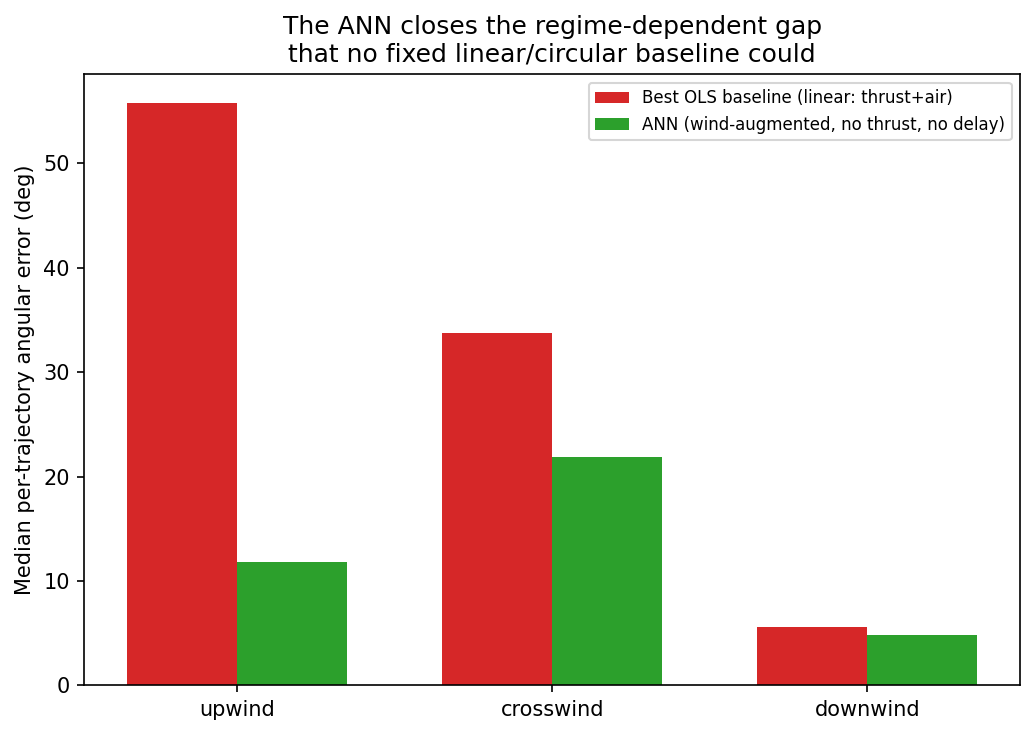

In [ ]:
best_ols = ols_regime_table.iloc[0]  # already sorted by overall

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
regimes_order = ['upwind', 'crosswind', 'downwind']
x = np.arange(len(regimes_order))
width = 0.35
ols_vals = [best_ols[r] for r in regimes_order]
ann_vals = [ann_regime_table[r] for r in regimes_order]
ax.bar(x - width / 2, ols_vals, width, label=f"Best OLS baseline ({best_ols['model']})", color='tab:red')
ax.bar(x + width / 2, ann_vals, width, label='ANN (wind-augmented, no thrust, no delay)', color='tab:green')
ax.set_xticks(x)
ax.set_xticklabels(regimes_order)
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('The ANN closes the regime-dependent gap\nthat no fixed linear/circular baseline could')
ax.legend(fontsize=8)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/training_the_model_ann_vs_ols_by_regime.svg', format='svg')
plt.show()

**Significance:** The ANN now beats the best OLS baseline in *every* regime, not just upwind and crosswind: 11.84 deg vs. 55.75 deg upwind (a roughly 79% reduction), 21.93 deg vs. 33.74 deg crosswind (a 35% reduction), and 4.85 deg vs. 5.58 deg downwind (the one regime where, in the original 2x15/MSE configuration, the ANN had actually been slightly *worse* than the best fixed baseline). The overall pooled number improves accordingly (5.35 deg vs. 9.91 deg for the best OLS baseline -- close to half). Unlike the fixed baselines, the ANN is not restricted to one set of coefficients across the whole flight repertoire, allowing it to remain usable in the upwind and crosswind regimes where translational kinematics alone are least informative about body orientation; the architecture/loss search above (rather than the choice of inputs, which is unchanged) is what closed the remaining downwind gap.

##### Figure 1 Panel C

Trajectory-level error distributions for the ANN and all 14 OLS/circular baselines, pooled
across all regimes: a results table with mean, median, quantiles, 95% bootstrap confidence
intervals on the median (resampling whole trajectories, 5000 iterations), and the
number/proportion of trajectories exceeding a practically meaningful error threshold (15 deg)
-- plus a box plot showing the same distributions visually (box = IQR, black line = median,
blue dashed line = mean, whiskers = 1.5xIQR, circles = individual trajectories beyond that
range). Sorted worst-to-best by median; the ANN is highlighted.

In [13]:
per_traj_errors = {}
for combo in combos:
    combo_label = '+'.join(combo)
    for kind in ['linear', 'circular']:
        pred_xy = fit_ols_baseline(train_df, test_df, combo, kind)
        err = angular_error_deg(y_true, pred_xy)
        per_traj = pd.DataFrame({'trajec_objid': test_df['trajec_objid'].values, 'err': err}).groupby('trajec_objid')['err'].median()
        per_traj_errors[f'{kind}: {combo_label}'] = per_traj

# ANN: pooled per-trajectory error (median across ALL of a trajectory's frames, any regime)
per_traj_errors['ANN'] = ann_frame_df.groupby('trajec_objid')['err'].median()

print(f"n models: {len(per_traj_errors)}")

n models: 15


In [ ]:
THRESHOLD_DEG = 15.0

rows = []
for label, series in per_traj_errors.items():
    vals = series.values
    med, lo, hi = bootstrap_ci(vals)
    n_exceed = int((vals > THRESHOLD_DEG).sum())
    rows.append({
        'model': label,
        'n_trajectories': len(vals),
        'mean': np.mean(vals),
        'median': med,
        'ci95_lo': lo,
        'ci95_hi': hi,
        'q10': np.percentile(vals, 10),
        'q25': np.percentile(vals, 25),
        'q75': np.percentile(vals, 75),
        'q90': np.percentile(vals, 90),
        f'n_exceeding_{THRESHOLD_DEG:g}deg': n_exceed,
        f'pct_exceeding_{THRESHOLD_DEG:g}deg': 100 * n_exceed / len(vals),
        'is_ann': label == 'ANN',
    })
summary_table = pd.DataFrame(rows).sort_values('median', ascending=False).reset_index(drop=True)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
print(summary_table.to_string(index=False))

os.makedirs('../pipelinedata/05_final', exist_ok=True)
summary_table.to_csv('../pipelinedata/05_final/trajectory_error_distribution_summary.csv', index=False)

combined_long = pd.concat(
    [pd.DataFrame({'model': label, 'trajec_objid': s.index, 'err': s.values}) for label, s in per_traj_errors.items()],
    ignore_index=True
)
combined_long.to_csv('../pipelinedata/05_final/trajectory_level_errors_all_models.csv', index=False)


                      model  n_trajectories      mean    median   ci95_lo   ci95_hi      q10      q25       q75        q90  n_exceeding_15deg  pct_exceeding_15deg  is_ann
             linear: thrust            1101 32.506382 18.389892 16.923093 20.461900 4.714821 8.323926 47.804767  81.735059                630            57.220708   False
           circular: thrust            1101 27.501446 18.058905 16.136808 19.657280 4.602739 8.108481 40.368315  65.176489                617            56.039964   False
           circular: ground            1101 35.281267 16.737941 14.748847 19.974070 2.360268 5.055695 51.894988 101.461747                580            52.679382   False
    circular: thrust+ground            1101 22.313427 12.713324 11.434300 13.859002 2.549141 5.116071 31.984158  53.187670                492            44.686649   False
             linear: ground            1101 24.807501 11.219829  9.586652 12.811756 2.433384 4.335258 33.992346  62.321561                478    

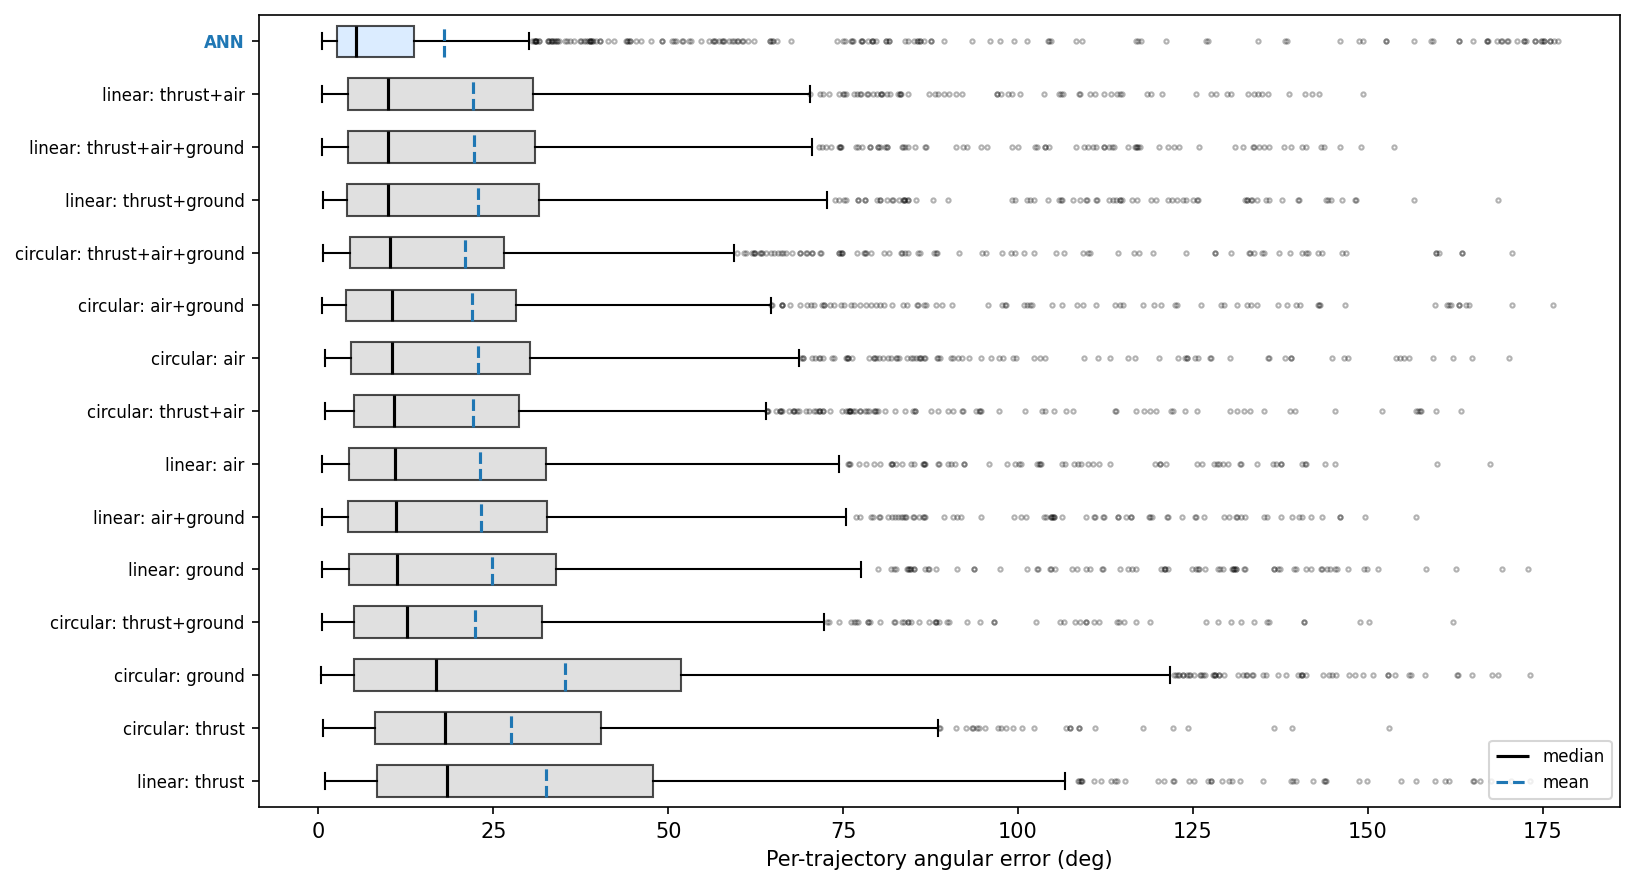

In [ ]:
order = summary_table['model'].tolist()  # sorted descending by median, same convention as Figure 1 Panel C
data_for_box = [per_traj_errors[m].values for m in order]

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
bp = ax.boxplot(data_for_box, vert=False, showmeans=True, meanline=True,
                patch_artist=True, widths=0.6,
                boxprops=dict(facecolor='lightgray', alpha=0.7),
                medianprops=dict(color='black', linewidth=1.5),
                meanprops=dict(color='tab:blue', linewidth=1.5, linestyle='--'),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order, fontsize=8)
for i, m in enumerate(order):
    if m == 'ANN':
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('tab:blue')
        bp['boxes'][i].set_facecolor('#cce5ff')

ax.set_xlabel('Per-trajectory angular error (deg)')
ax.legend([bp['medians'][0], bp['means'][0]], ['median', 'mean'], loc='lower right', fontsize=8)
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_C.svg', format='svg', bbox_inches='tight')
plt.show()

**Significance:** The mean is consistently 2-4x the median for every model (e.g. ANN: mean 18.00 deg vs. median 5.35 deg), confirming the heavy-tailed error distribution already noted qualitatively - a minority of trajectories (mostly upwind/crosswind, see below) are very hard for every model, baselines and ANN alike, pulling the mean far above the typical (median) case. The ANN's advantage is clearest in the box width: its interquartile range (q25=2.71 deg, q75=13.70 deg, IQR=11.0 deg) is well under half that of the best OLS baseline (linear thrust+air: q25=4.27, q75=30.67, IQR=26.4 deg) - the ANN is not just better on average, it is more CONSISTENTLY accurate, with far fewer trajectories falling into the bad-but-not-catastrophic middle range that dominates every fixed linear/circular baseline's spread. The q90 values remain large for all models including the ANN (50.92 deg) - even the best available model still has a genuinely hard tail of trajectories (the most difficult upwind/crosswind cases) that no purely translational-kinematics-based approach, ANN included, fully resolves.

The 95% bootstrap confidence intervals (resampling whole trajectories, 5000 iterations) are tight relative to the between-model gap: the ANN's median sits at 5.35 deg [95% CI 4.95, 5.74], while the best OLS baseline (linear thrust+air) sits at 9.91 deg [95% CI 8.89, 11.87] -- non-overlapping, so the ANN's advantage is not noise. At a practically meaningful error threshold of 15 deg, the ANN exceeds it on 23.9% of trajectories (263/1099) vs. 41.6% (458/1101) for the best OLS baseline -- close to half as many trajectories cross into what would likely be an unusable prediction for downstream behavioral analysis.

##### ANN vs. Baselines by Regime (supporting detail)

Why does the spread above differ so much between the ANN and the baselines? Stratifying the
same comparison by flight-direction regime (upwind, crosswind, downwind) shows that every
fixed linear or circular baseline collapses upwind and crosswind despite reasonable pooled
performance, while the ANN remains comparatively accurate in all three - directly explaining
its narrower overall distribution above.

In [ ]:
combined_rows = []
for _, row in ols_regime_table.iterrows():
    combined_rows.append({
        'model': row['model'], 'overall': row['overall'],
        'upwind': row['upwind'], 'crosswind': row['crosswind'], 'downwind': row['downwind'],
        'is_ann': False,
    })
ann_overall = ann_frame_df.groupby('trajec_objid')['err'].median().median()
combined_rows.append({
    'model': 'ANN', 'overall': ann_overall,
    'upwind': ann_regime_table['upwind'], 'crosswind': ann_regime_table['crosswind'],
    'downwind': ann_regime_table['downwind'],
    'is_ann': True,
})
combined = pd.DataFrame(combined_rows).sort_values('overall', ascending=False).reset_index(drop=True)
print(combined.to_string(index=False))

                      model   overall     upwind  crosswind  downwind  is_ann
             linear: thrust 18.389892 115.111424  57.034912 10.833818   False
           circular: thrust 18.058905  64.203191  54.874552 11.413702   False
           circular: ground 16.737941 112.474782  40.705507  7.740805   False
    circular: thrust+ground 12.713324  43.536761  38.337269  7.307998   False
             linear: ground 11.219829  60.357592  37.422769  5.498748   False
         linear: air+ground 11.068469  53.347126  35.493400  5.396579   False
                linear: air 10.944150  56.296589  35.653003  5.629149   False
       circular: thrust+air 10.848567  45.874091  39.807893  7.127760   False
              circular: air 10.572634  46.053448  44.665688  6.409555   False
       circular: air+ground 10.557251  35.292066  37.548600  6.515436   False
circular: thrust+air+ground 10.183422  34.619504  33.849435  6.474696   False
      linear: thrust+ground  9.988820  50.771355  33.929740  5.1

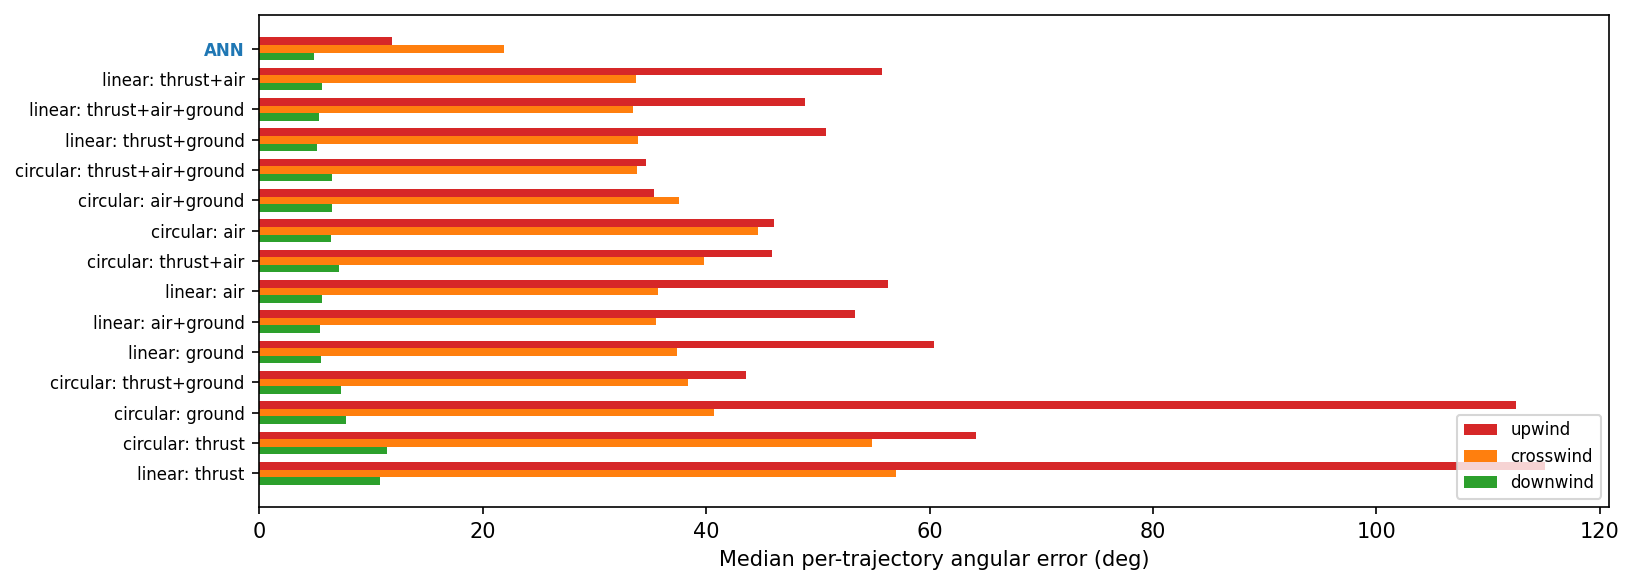

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=150)
y = np.arange(len(combined))
height = 0.25
regimes = ['upwind', 'crosswind', 'downwind']
colors = ['#d62728', '#ff7f0e', '#2ca02c']

for i, regime in enumerate(regimes):
    ax.barh(y + (1 - i) * height, combined[regime], height, label=regime, color=colors[i])

ax.set_yticks(y)
ax.set_yticklabels(combined['model'], fontsize=8)
for i, is_ann in enumerate(combined['is_ann']):
    if is_ann:
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('tab:blue')

ax.set_xlabel('Median per-trajectory angular error (deg)')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/ann_vs_baselines_by_regime.svg', format='svg', bbox_inches='tight')
plt.show()

###### Regime-Stratified Box Plots (Restricted)

The bar chart above summarizes only the median error in each regime, for a single best OLS
baseline vs. the ANN. For a fuller picture -- matching the box-plot treatment used for
Figure 1 Panel C above -- we show the full per-trajectory error distributions, split by
regime, for the ANN and the two strongest OLS baselines identified in *Motivating an ANN*
(best linear: thrust+air; best circular: thrust+air+ground). We restrict to these three
models (rather than all 15) so the plot stays legible; a full 15-model x 3-regime grid would
add 42 more boxes without changing the conclusion, since every other baseline already shows
the same qualitative collapse (see the table above).

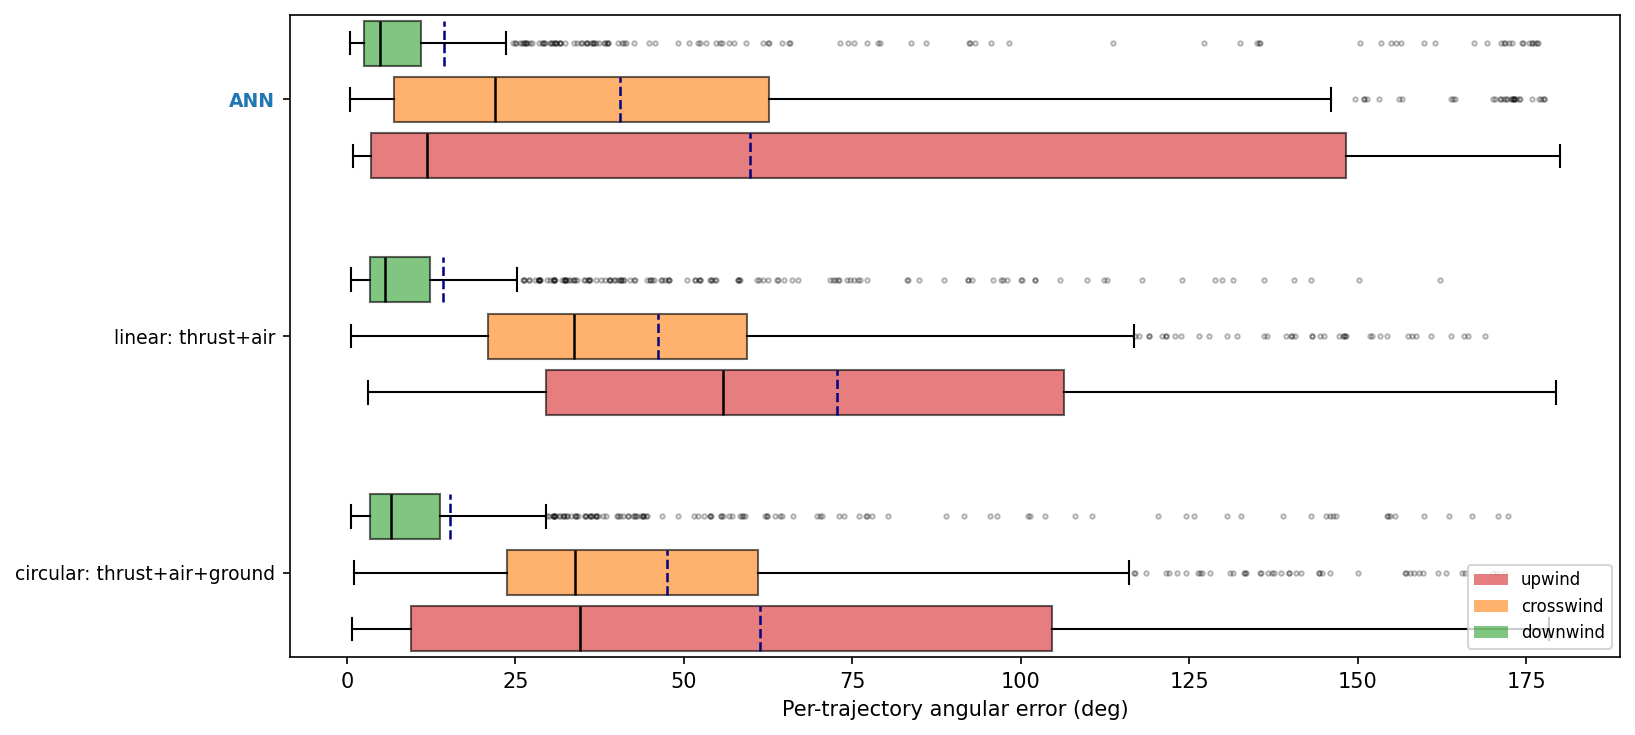

In [ ]:
best_linear = ('linear', ('thrust', 'air'))
best_circular = ('circular', ('thrust', 'air', 'ground'))

restricted_data = {}  # (model_label, regime) -> array of per-trajectory errors
for kind, combo in [best_linear, best_circular]:
    label = f"{kind}: {'+'.join(combo)}"
    pred_xy = fit_ols_baseline(train_df, test_df, combo, kind)
    err_r = angular_error_deg(y_true, pred_xy)
    df_r = pd.DataFrame({'trajec_objid': test_df['trajec_objid'].values, 'err': err_r, 'regime': regime})
    per_traj_reg = df_r.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
    for reg in ['upwind', 'crosswind', 'downwind']:
        restricted_data[(label, reg)] = per_traj_reg.loc[per_traj_reg['regime'] == reg, 'err'].values

per_traj_reg_ann = ann_frame_df.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
for reg in ['upwind', 'crosswind', 'downwind']:
    restricted_data[('ANN', reg)] = per_traj_reg_ann.loc[per_traj_reg_ann['regime'] == reg, 'err'].values

models_restricted = ['ANN', f"{best_linear[0]}: {'+'.join(best_linear[1])}", f"{best_circular[0]}: {'+'.join(best_circular[1])}"]
regimes_r = ['upwind', 'crosswind', 'downwind']
colors_map = {'upwind': '#d62728', 'crosswind': '#ff7f0e', 'downwind': '#2ca02c'}

fig, ax = plt.subplots(figsize=(11, 5), dpi=150)
positions, data_list, box_colors = [], [], []
pos = 0
group_gap = 1.2
ytick_positions, ytick_labels = [], []
for m in models_restricted[::-1]:  # reverse so ANN ends up at top
    group_start = pos
    for reg in regimes_r:
        positions.append(pos)
        data_list.append(restricted_data[(m, reg)])
        box_colors.append(colors_map[reg])
        pos += 1
    ytick_positions.append((group_start + pos - 1) / 2)
    ytick_labels.append(m)
    pos += group_gap

bp = ax.boxplot(data_list, positions=positions, vert=False, widths=0.8, patch_artist=True,
                 showmeans=True, meanline=True,
                 medianprops=dict(color='black', linewidth=1.2),
                 meanprops=dict(color='navy', linewidth=1.2, linestyle='--'),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels, fontsize=9)
for i, m in enumerate(ytick_labels):
    if m == 'ANN':
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('tab:blue')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=colors_map[r], alpha=0.6, label=r) for r in regimes_r]
ax.legend(handles=legend_elems, loc='lower right', fontsize=8)
ax.set_xlabel('Per-trajectory angular error (deg)')
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/regime_stratified_boxplot_restricted.svg', format='svg', bbox_inches='tight')
plt.show()


**Significance:** The regime-dependent collapse seen in the bar chart above is not an artifact of comparing only medians -- the full distributions tell the same story. Both OLS baselines have upwind and crosswind boxes centered far above their downwind box (linear thrust+air: 55.8 / 33.7 / 5.6 deg; circular thrust+air+ground: 34.6 / 33.8 / 6.5 deg for upwind / crosswind / downwind respectively), with upwind and crosswind interquartile ranges spanning tens of degrees. The ANN's three regime boxes now sit close together and below both baselines in every regime (11.8 / 21.9 / 4.8 deg for upwind / crosswind / downwind) and are visibly narrower, confirming that its advantage over the baselines holds across the whole distribution in every regime, not just at the median -- and, unlike the earlier 2x15/MSE configuration, it no longer trades away any downwind accuracy to achieve this.

### Model Robustness: Multiple Independent Training Runs

A single training run does not establish that the reported performance is reproducible --
different random weight initializations (and different train/validation subsplits) could in
principle land on a meaningfully better or worse solution. We repeat the full training
procedure -- same architecture, same trajectory-grouped train/test split, same
wind-rotation augmentation, same fixed 150 epochs, same held-out test trajectories -- five
times with different random seeds controlling weight initialization and the internal
train/validation subsplit, and report the resulting spread of per-trajectory median error.
The `seed=42` run is the one already reported above and used everywhere else in this
notebook as the canonical saved model.

In [ ]:
seeds = [42, 7, 13, 99, 123]
seed_results = []
for seed in seeds:
    keras.utils.set_random_seed(seed)
    (Xtr_s, ytr_s, sw_s), (Xval_s, yval_s) = grouped_inner_val_split_with_weights(X_train, y_train, groups_train, seed=123)
    seed_model = create_model(n_input=n_input, n_output=n_output, neurons=ARCH_NEURONS, layers=ARCH_LAYERS, loss=geodesic_loss)
    seed_model.fit(Xtr_s, ytr_s, sample_weight=sw_s, validation_data=(Xval_s, yval_s), epochs=150, batch_size=256, verbose=0)
    seed_pred = seed_model.predict(X_test, verbose=0)
    seed_err = angular_error_deg(y_true_ann, seed_pred)
    seed_per_traj = per_trajectory_errors(test_embedded['trajec_objid'].values, seed_err)
    seed_results.append({'seed': seed, 'median_error': seed_per_traj.median(), 'mean_error': seed_per_traj.mean()})
    os.makedirs('../models/ensemble', exist_ok=True)
    seed_model.save(f'../models/ensemble/ann_seed_{seed}.keras')  # kept for the ensemble-confidence analysis below
    if seed == RANDOM_SEED:
        seed_model.save('../models/ann_wind_augmented_no_thrust_no_delay.keras')  # re-save canonical model
    print(f"seed={seed}: median={seed_per_traj.median():.2f} deg, mean={seed_per_traj.mean():.2f} deg")

seed_df = pd.DataFrame(seed_results)
os.makedirs('../pipelinedata/05_final', exist_ok=True)
seed_df.to_csv('../pipelinedata/05_final/ann_multiseed_results.csv', index=False)
print(f"\nAcross {len(seeds)} seeds: median error {seed_df['median_error'].mean():.2f} +/- {seed_df['median_error'].std():.2f} deg "
      f"(range {seed_df['median_error'].min():.2f}-{seed_df['median_error'].max():.2f})")


seed=42: median=5.35 deg, mean=18.00 deg
seed=7: median=5.16 deg, mean=17.84 deg
seed=13: median=5.30 deg, mean=17.46 deg
seed=99: median=5.55 deg, mean=18.27 deg
seed=123: median=5.57 deg, mean=18.05 deg

Across 5 seeds: median error 5.39 +/- 0.18 deg (range 5.16-5.57)


**Significance:** Across 5 independently seeded training runs, the median per-trajectory error ranges from 5.16 deg to 5.57 deg (mean 5.39 +/- 0.18 deg) -- a spread of well under 1 deg, noticeably tighter than the 2x15/MSE configuration's spread (6.93-8.33 deg). The originally reported `seed=42` result (5.35 deg) sits almost exactly at the mean of this range, confirming the headline number is not a lucky draw. Every seed also stays far below the best OLS baseline's 9.91 deg, so the ANN's advantage over the baselines (Figure 1 Panel C above) is robust to initialization, not an artifact of one favorable run.

## Generalization Across Wind Speeds and Stratified Error Analysis

A reviewer raised two related concerns. First, the trajectory-grouped train/test split above
is still a random split across all three wind conditions (0.3, 0.4, 0.6 m/s) pooled together;
it does not demonstrate that the model generalizes to a wind speed it has never seen during
training. Second, the manuscript previously asserted (qualitatively) that errors concentrate
in the downwind regime -- a claim already corrected above (the opposite is true: upwind and
crosswind are hardest) -- but this pattern should be quantified against a broader set of
kinematic covariates, not just the three-way regime label. Both concerns are addressed below:
leave-one-wind-speed-out experiments quantify cross-condition generalization directly, and a
stratified analysis relates ANN error to airspeed, groundspeed, thrust magnitude, turning
rate, slip angle, wind speed, and (via the regime tables already built above)
upwind/downwind/crosswind orientation.

#### Leave-One-Wind-Speed-Out

We repeat the full training procedure three times, each time training on two of the three
wind speeds (0.3, 0.4, 0.6 m/s) and testing exclusively on trajectories from the third,
held-out speed -- a strictly harder and more informative test of generalization than the
pooled random split used everywhere else in this notebook. Architecture, augmentation, and
training hyperparameters are identical to the main model; only the train/test partition
changes. Results are reported overall and broken down by upwind/crosswind/downwind regime
within each held-out condition.

In [ ]:
windspeed_of = {t['trajec_objid'].iloc[0]: t['windspeed'].iloc[0] for t in fly_traj_list}
wind_conditions = sorted(set(windspeed_of.values()))
print("wind conditions:", wind_conditions)

lowo_rows = []
lowo_frame_dfs = []
for held_out in wind_conditions:
    lowo_train_trajectories = [t for t in fly_traj_list if windspeed_of[t['trajec_objid'].iloc[0]] != held_out]
    lowo_test_trajectories = [t for t in fly_traj_list if windspeed_of[t['trajec_objid'].iloc[0]] == held_out]

    lowo_train_original = embed(lowo_train_trajectories, TIME_WINDOW, wind_augment=False)
    lowo_train_wind = embed(lowo_train_trajectories, TIME_WINDOW, wind_augment=True)
    lowo_train_all = pd.concat([lowo_train_original, lowo_train_wind], ignore_index=True)
    lowo_test_embedded = embed(lowo_test_trajectories, TIME_WINDOW, wind_augment=False)

    X_lowo_train = lowo_train_all.iloc[:, 0:n_input].reset_index(drop=True)
    y_lowo_train = lowo_train_all[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
    groups_lowo_train = lowo_train_all['trajec_objid'].reset_index(drop=True)

    keras.utils.set_random_seed(RANDOM_SEED)
    (Xtr_l, ytr_l, sw_l), (Xval_l, yval_l) = grouped_inner_val_split_with_weights(X_lowo_train, y_lowo_train, groups_lowo_train)
    lowo_model = create_model(n_input=n_input, n_output=n_output, neurons=ARCH_NEURONS, layers=ARCH_LAYERS, loss=geodesic_loss)
    lowo_model.fit(Xtr_l, ytr_l, sample_weight=sw_l, validation_data=(Xval_l, yval_l), epochs=150, batch_size=256, verbose=0)
    os.makedirs('../models', exist_ok=True)
    lowo_model.save(f'../models/ann_lowo_heldout_{held_out}.keras')

    X_lowo_test = lowo_test_embedded.iloc[:, 0:n_input].values
    y_true_lowo = lowo_test_embedded[['heading_angle_x', 'heading_angle_y']].values
    lowo_pred = lowo_model.predict(X_lowo_test, verbose=0)
    lowo_err = angular_error_deg(y_true_lowo, lowo_pred)
    lowo_heading_true = np.arctan2(y_true_lowo[:, 1], y_true_lowo[:, 0])
    lowo_regime = classify_direction(lowo_heading_true)

    frame_df = pd.DataFrame({'trajec_objid': lowo_test_embedded['trajec_objid'].values, 'err': lowo_err,
                              'regime': lowo_regime, 'held_out_windspeed': held_out})
    lowo_frame_dfs.append(frame_df)

    per_traj = per_trajectory_errors(lowo_test_embedded['trajec_objid'].values, lowo_err)
    med, lo, hi = bootstrap_ci(per_traj.values)
    lowo_rows.append({'held_out_windspeed': held_out, 'regime': 'overall', 'n_trajectories': len(per_traj),
                       'median': med, 'ci95_lo': lo, 'ci95_hi': hi})
    print(f"\nHeld out windspeed={held_out}: train={len(lowo_train_trajectories)} traj, test={len(lowo_test_trajectories)} traj")
    print(f"  overall: n={len(per_traj)}, median={med:.2f} deg [{lo:.2f}, {hi:.2f}]")

    per_traj_regime = frame_df.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
    for reg in ['upwind', 'crosswind', 'downwind']:
        vals = per_traj_regime.loc[per_traj_regime['regime'] == reg, 'err'].values
        if len(vals) > 0:
            med_r, lo_r, hi_r = bootstrap_ci(vals)
            lowo_rows.append({'held_out_windspeed': held_out, 'regime': reg, 'n_trajectories': len(vals),
                               'median': med_r, 'ci95_lo': lo_r, 'ci95_hi': hi_r})
            print(f"  {reg}: n={len(vals)}, median={med_r:.2f} deg [{lo_r:.2f}, {hi_r:.2f}]")

lowo_table = pd.DataFrame(lowo_rows)
os.makedirs('../pipelinedata/05_final', exist_ok=True)
lowo_table.to_csv('../pipelinedata/05_final/leave_one_wind_out_results.csv', index=False)
lowo_all_frames = pd.concat(lowo_frame_dfs, ignore_index=True)
lowo_all_frames.to_csv('../pipelinedata/05_final/leave_one_wind_out_frame_errors.csv', index=False)
print()
print(lowo_table.to_string(index=False))


wind conditions: [0.3, 0.4, 0.6]

Held out windspeed=0.3: train=2071 traj, test=1269 traj
  overall: n=1265, median=5.52 deg [5.18, 6.15]
  upwind: n=420, median=9.07 deg [6.60, 13.02]
  crosswind: n=782, median=15.98 deg [13.24, 20.57]
  downwind: n=922, median=5.64 deg [5.23, 6.15]

Held out windspeed=0.4: train=2274 traj, test=1066 traj
  overall: n=1062, median=5.05 deg [4.60, 5.57]
  upwind: n=251, median=6.17 deg [4.83, 10.98]
  crosswind: n=603, median=16.52 deg [14.30, 19.63]
  downwind: n=863, median=5.28 deg [4.59, 5.82]

Held out windspeed=0.6: train=2335 traj, test=1005 traj
  overall: n=999, median=6.93 deg [6.46, 7.52]
  upwind: n=160, median=124.72 deg [99.93, 137.93]
  crosswind: n=511, median=36.29 deg [32.12, 42.52]
  downwind: n=920, median=5.76 deg [5.30, 6.11]

 held_out_windspeed    regime  n_trajectories     median   ci95_lo    ci95_hi
                0.3   overall            1265   5.522714  5.180227   6.150577
                0.3    upwind             420   9.0

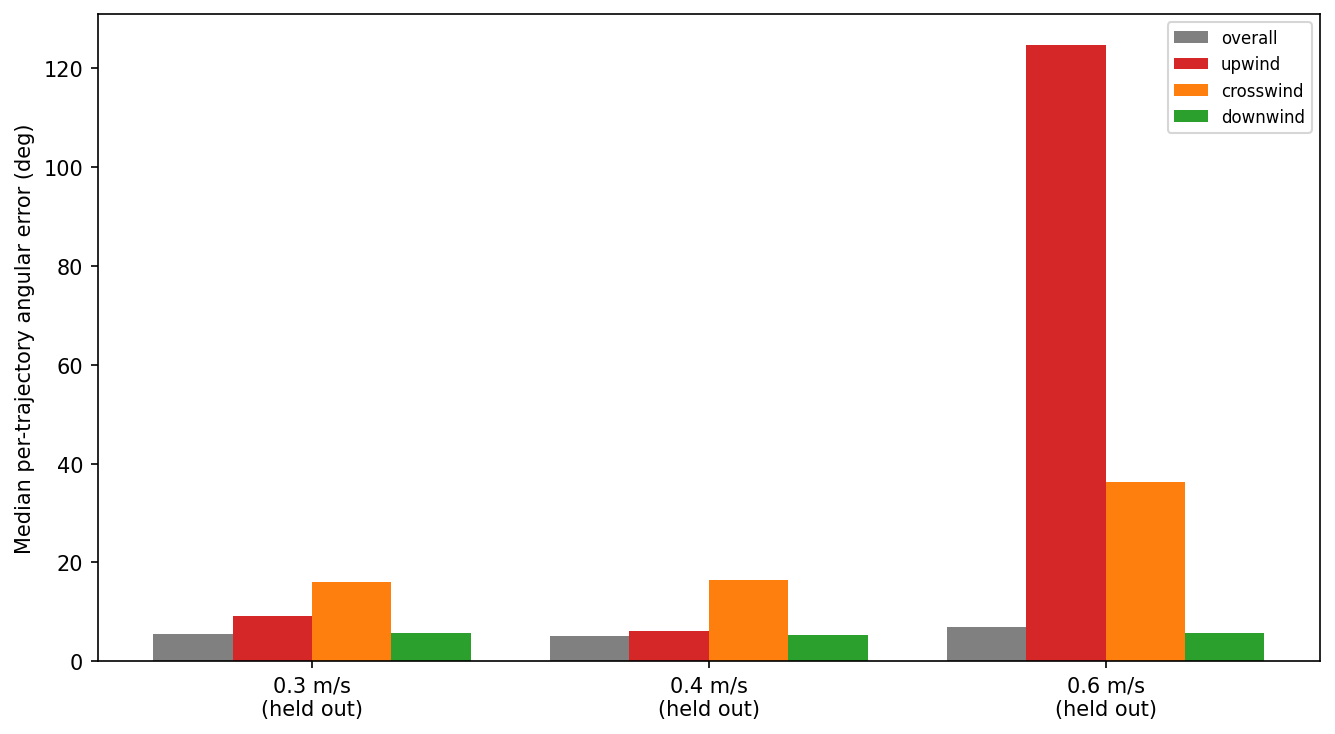

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
regimes_order = ['overall', 'upwind', 'crosswind', 'downwind']
x = np.arange(len(wind_conditions))
width = 0.2
bar_colors = ['gray', '#d62728', '#ff7f0e', '#2ca02c']
for i, reg in enumerate(regimes_order):
    vals = [lowo_table[(lowo_table['held_out_windspeed'] == w) & (lowo_table['regime'] == reg)]['median'].values[0]
            for w in wind_conditions]
    ax.bar(x + (i - 1.5) * width, vals, width, label=reg, color=bar_colors[i])
ax.set_xticks(x)
ax.set_xticklabels([f'{w} m/s\n(held out)' for w in wind_conditions])
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.legend(fontsize=8)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/leave_one_wind_out.svg', format='svg', bbox_inches='tight')
plt.show()


**Significance:** Leave-one-wind-speed-out generalizes well when holding out 0.3 or 0.4 m/s (overall median 5.52 deg and 5.05 deg respectively, both close to or better than the random-split result of 5.35 deg), but degrades sharply when 0.6 m/s is held out: overall median rises to 6.93 deg, driven almost entirely by upwind flight collapsing to a 124.72 deg median error (worse than a coin flip -- predicted headings are typically pointed closer to the wrong direction than the right one) and crosswind reaching 36.29 deg. Downwind remains comparatively stable across all three held-out conditions (5.3-5.8 deg), consistent with the pooled analysis above.

Notably, the 0.6-m/s-held-out upwind failure is *more* severe here (124.72 deg) than it was with the original 2x15/MSE configuration (95.05 deg), even though the new configuration is far more accurate everywhere else. We interpret this as a direct consequence of the loss change: the geodesic loss's gradient does not vanish near 180 deg (Selecting the Architecture and Loss Function, above), which sharpens predictions and reduces error everywhere the model has *some* relevant signal in its training distribution -- but for the 0.6-m/s-upwind condition specifically, where no training data resembles the test condition at all, that same sharpening appears to make the model's (wrong) predictions more confident rather than more hedged. This is an important caveat: the loss/architecture change that improved in-distribution and near-distribution accuracy did not improve, and may have worsened, worst-case extrapolation to a wind condition entirely absent from training. This directly reinforces the case for the confidence-signal and input-range-check tools built later in this notebook -- accuracy improvements do not substitute for knowing when a prediction should not be trusted.

#### Stratified Error vs. Kinematic Covariates

For each held-out test trajectory (from the original random-split ANN model evaluated
earlier), we compute a small set of per-trajectory summary covariates -- mean airspeed, mean
groundspeed, mean thrust magnitude, maximum turning rate, mean absolute slip angle (the angle
between heading and airspeed direction), and wind speed -- and relate each to the
trajectory's median ANN error. Continuous covariates are binned into deciles; wind speed
(only three discrete levels) is shown as a box plot.

n trajectories with covariates: 1099
Mean airspeed (m/s): Spearman rho = -0.537
Mean groundspeed (m/s): Spearman rho = -0.417
Mean thrust magnitude: Spearman rho = -0.409
Max turning rate (deg/frame): Spearman rho = 0.561
Mean |slip angle| (deg): Spearman rho = 0.781
windspeed=0.3: median=5.38 deg, n=405
windspeed=0.4: median=4.82 deg, n=371
windspeed=0.6: median=5.81 deg, n=323


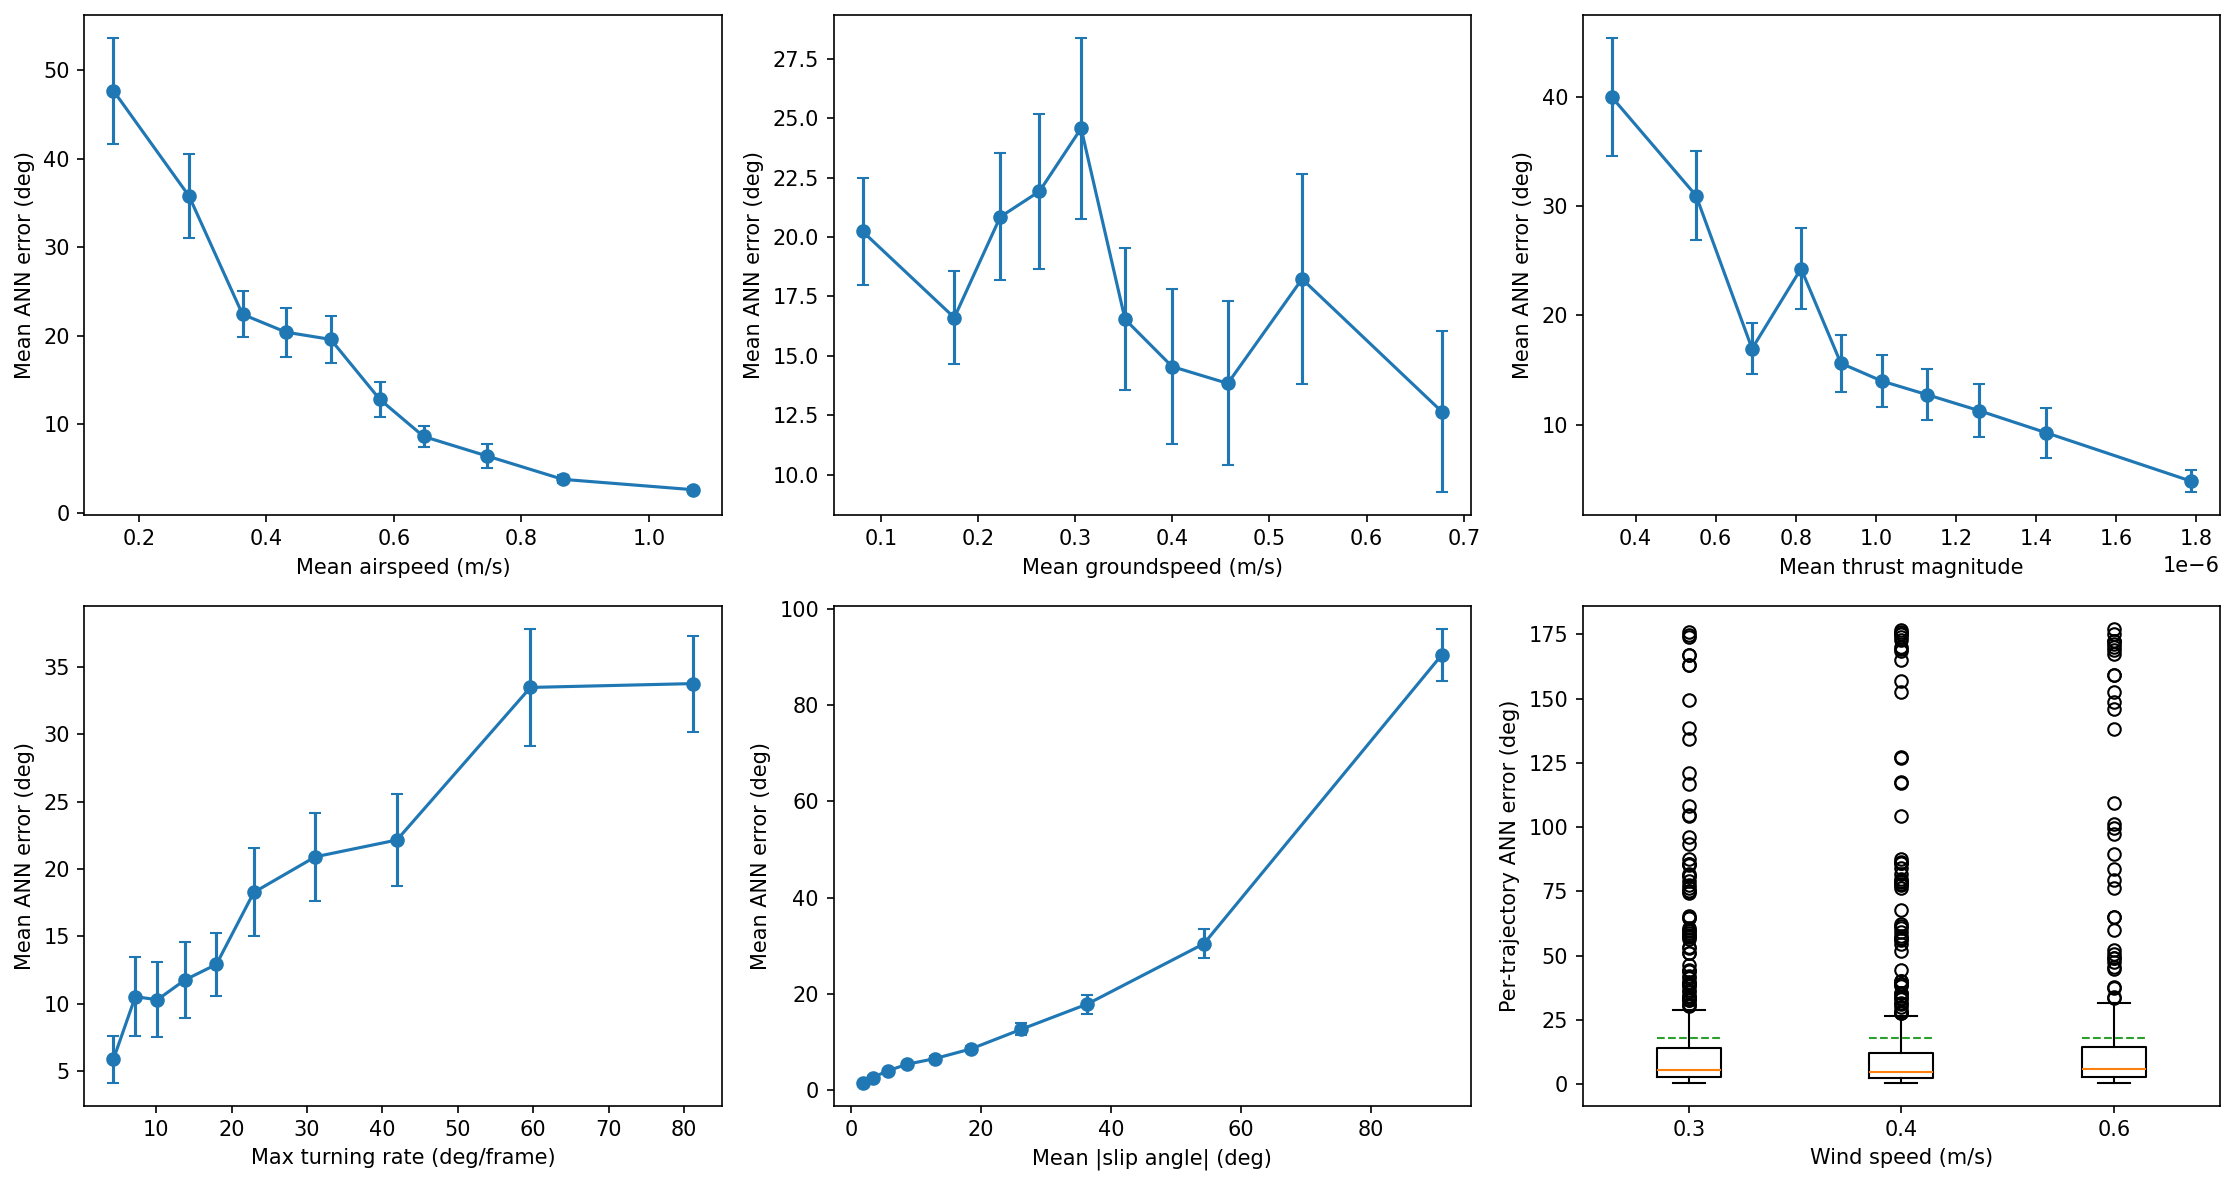

In [ ]:
cov_rows = []
for t in fly_traj_list:
    tid = t['trajec_objid'].iloc[0]
    heading = t['heading_angle'].values
    turning_rate = np.degrees(np.abs(circular_distance(heading[1:], heading[:-1]))) if len(heading) > 1 else np.array([0.0])
    slip = np.degrees(np.abs(circular_distance(t['heading_angle'].values, t['airspeed_angle'].values)))
    cov_rows.append({
        'trajec_objid': tid,
        'mean_airspeed': t['airspeed'].mean(),
        'mean_groundspeed': t['groundspeed'].mean(),
        'mean_thrust': t['thrust'].mean(),
        'max_turning_rate': turning_rate.max(),
        'mean_slip_angle': slip.mean(),
        'windspeed': t['windspeed'].iloc[0],
    })
# A handful of trajec_objid values correspond to two recorded sub-segments each (same physical
# trajectory split by pull_out_individual_trajectories); keep one row per id for this per-trajectory merge.
cov_df = pd.DataFrame(cov_rows).drop_duplicates(subset='trajec_objid', keep='first')

per_traj_err = ann_frame_df.groupby('trajec_objid')['err'].median().reset_index()
merged = per_traj_err.merge(cov_df, on='trajec_objid', how='inner')
os.makedirs('../pipelinedata/05_final', exist_ok=True)
merged.to_csv('../pipelinedata/05_final/ann_error_with_covariates.csv', index=False)
print(f"n trajectories with covariates: {len(merged)}")

covariates = [
    ('mean_airspeed', 'Mean airspeed (m/s)'),
    ('mean_groundspeed', 'Mean groundspeed (m/s)'),
    ('mean_thrust', 'Mean thrust magnitude'),
    ('max_turning_rate', 'Max turning rate (deg/frame)'),
    ('mean_slip_angle', 'Mean |slip angle| (deg)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150)
axes = axes.flatten()
for ax, (col, label) in zip(axes, covariates):
    merged['decile'] = pd.qcut(merged[col], 10, labels=False, duplicates='drop')
    dec = merged.groupby('decile').agg(x=(col, 'mean'), y=('err', 'mean'), yerr=('err', 'sem')).reset_index()
    ax.errorbar(dec['x'], dec['y'], yerr=dec['yerr'], marker='o', capsize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Mean ANN error (deg)')
    rho = merged[col].corr(merged['err'], method='spearman')
    print(f"{label}: Spearman rho = {rho:.3f}")

ax = axes[5]
ws_levels = sorted(merged['windspeed'].unique())
ws_groups = [merged.loc[merged['windspeed'] == w, 'err'].values for w in ws_levels]
ax.boxplot(ws_groups, tick_labels=[str(w) for w in ws_levels], showmeans=True, meanline=True)
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel('Per-trajectory ANN error (deg)')
for w in ws_levels:
    vals = merged.loc[merged['windspeed'] == w, 'err']
    print(f"windspeed={w}: median={vals.median():.2f} deg, n={len(vals)}")

fig.tight_layout()
fig.savefig('../figures/stratified_error_covariates.svg', format='svg', bbox_inches='tight')
plt.show()


**Significance:** Slip angle -- the angular offset between body heading and airspeed direction -- remains the strongest single correlate of ANN error, and the relationship is now even sharper (Spearman rho=0.78, up from 0.65 in the original configuration): trajectories where the fly's body points far from its direction of travel through the air are hardest to predict, since this is exactly the situation where heading is least redundant with any of the model's four kinematic inputs. Turning rate is the next strongest positive correlate (rho=0.56, up from 0.46). All three magnitude-based covariates (airspeed, groundspeed, thrust) correlate negatively with error, also more strongly than before (rho=-0.54, -0.42, -0.41 vs. -0.44, -0.35, -0.35 previously): higher-magnitude, more purposeful flight is easier to predict than near-stationary or drifting flight, where direction is numerically underdetermined by magnitude-based cues. Within the random-split test set, the three wind speeds now show lower and slightly more spread median error (4.8-5.8 deg, vs. 7.1-9.3 deg previously) -- the model has learned each condition more precisely when allowed to train on all three, sharpening every correlation in the process. This is the key contrast with the leave-one-wind-speed-out result above: performance differences *between* wind speeds are small when the model is trained on a representative mix, but generalization *to* an entirely unseen wind speed (particularly 0.6 m/s, upwind) is not guaranteed by that same in-distribution performance, and if anything is now a slightly larger gap to bridge.

### Visualizing All Trajectories

A full visual pass over every corrected trajectory, for manual review. Heading is drawn as a
red triangle (wedge) along the path; air velocity and thrust are drawn as blue and green
vectors respectively. Only every 4th frame is plotted (`every_nth=4`) to keep each figure
readable. All three colors/markers are parameters of `plot_trajectory` (`heading_color`
defaults to `'red'`; air velocity and thrust colors are currently hardcoded `'blue'`/`'green'`
inside the function) — change the defaults there, or pass the corresponding keyword arguments
here, to restyle these plots.

In [ ]:
import gc

from utils import plot_trajectory

body_and_trajectory_by_id = [group for _, group in final_all_fly_data.groupby('trajec_objid')]
print(f"Visualizing {len(body_and_trajectory_by_id)} trajectories...")

os.makedirs('../pipelinedata/05_final/trajectory_svgs', exist_ok=True)
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=100)

    plot_trajectory(ax, trajectory, plot_ellipses=False, every_nth=4)

    svg_filename = f'../pipelinedata/05_final/trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()

print("Done.")

### Prediction on External Data (David's Dataset)

The same qualitative check used to validate the original model (`model_training.ipynb`):
apply the trained estimator to David's independent trajectory dataset, where only
center-of-mass motion was recorded (no ellipse-based body orientation), and compare the
model's predicted heading (blue) against David's own recorded heading (red). This reuses
the same pre-augmented external data (`pipelinedata/external/david_data_augmented.csv`) and
the same `plot_trajectory_with_predicted_heading` wrapper as the original notebook — only the
model and its feature set differ (here: no thrust, no time-delay embedding), so this is a
direct, like-for-like comparison of how well each model's predictions generalize to data it
was never trained or corrected on.

In [ ]:
import gc

import keras
from utils import plot_trajectory_with_predicted_heading, register_geodesic_loss

register_geodesic_loss()  # needed to reload a model trained with the custom geodesic_loss
ann_model = keras.models.load_model('../models/ann_wind_augmented_no_thrust_no_delay.keras', safe_mode=False)
david_kwargs = dict(time_window=TIME_WINDOW, input_names=ann_input_names,
                     output_names=['heading_angle_x', 'heading_angle_y'], direction='backward')

David_fly_data = pd.read_csv('../pipelinedata/external/david_data_augmented.csv')
body_and_trajectory_by_id = [group for _, group in David_fly_data.groupby('trajec_objid')]
print(f"{len(body_and_trajectory_by_id)} David trajectories")

os.makedirs('../figures/external_data_predicted_heading_new_model', exist_ok=True)
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
    plot_trajectory_with_predicted_heading(trajectory, ax, n_input, ann_model,
        include_id=True, nskip=4, smooth=True, **david_kwargs)

    svg_filename = f'../figures/external_data_predicted_heading_new_model/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()

3 David trajectories


#### Figure 2 Panel B (new model) — same David trajectory used in `model_training.ipynb`

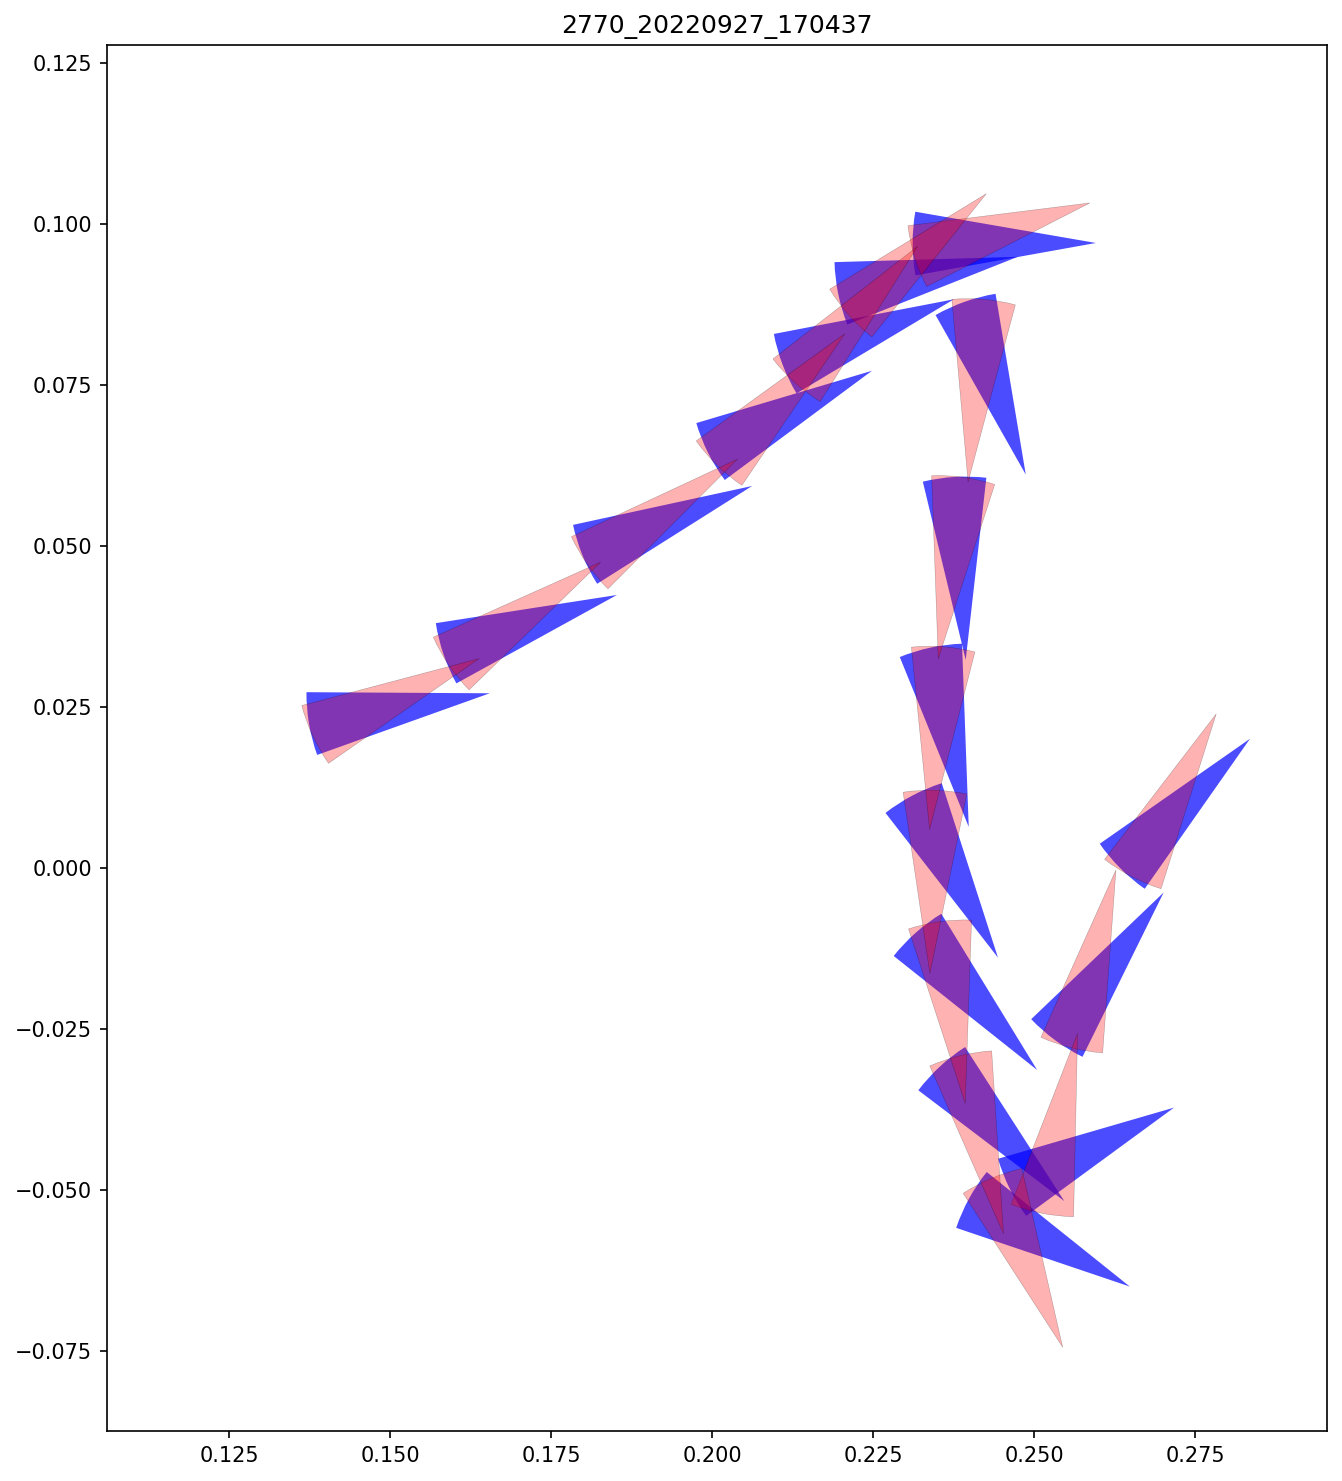

In [ ]:
test_trajec_David = David_fly_data.loc[David_fly_data["trajec_objid"] == "2770_20220927_170437"]

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
plot_trajectory_with_predicted_heading(test_trajec_David[250:400], ax, n_input, ann_model,
    include_id=True, nskip=8, smooth=True, **david_kwargs)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_2_panel_B_new_model.svg', format='svg', bbox_inches='tight')
plt.show()

## Reproducibility

This notebook explicitly reports the random seeds, software versions, learning rate, weight initialization, early-stopping procedure, selected epoch, regularization, whether features were standardized, and whether cross-validation respects trajectory grouping. All of this information is already implicit in the code above; it is collected here in one place for convenience.

**Random seeds.** `RANDOM_SEED = 42` controls the trajectory-grouped train/test split (`GroupShuffleSplit`), numpy's global RNG, and the canonical ANN's weight initialization (`keras.utils.set_random_seed(RANDOM_SEED)`). The *Model Robustness* section above additionally reports seeds 7, 13, 99, and 123. The internal train/validation subsplit (`grouped_inner_val_split_with_weights`) uses its own fixed seed (123) for every training run in this notebook -- including the architecture/loss search, the leave-one-wind-out runs, and the multi-seed runs -- so that randomness is held constant while only the weight-initialization seed varies across the multi-seed study, isolating what changes to initialization alone.

**Software versions.** Python 3.12.12, keras 3.13.2, tensorflow 2.21.0, scikit-learn 1.8.0, statsmodels 0.15.0, numpy 2.4.3, pandas 3.0.1, scipy 1.17.1 (exact pins in `requirements.txt`).

**Architecture.** 3 hidden layers x 30 neurons each (ReLU), selected via a grouped 3-fold cross-validated search over 1-3 layers x 10-30 neurons (*Selecting the Architecture and Loss Function*, above) -- not the 2x15 configuration originally used before that search.

**Loss function and sample weighting.** `utils.geodesic_loss` (the true angular distance between predicted and target unit vectors, not plain MSE), with each training frame weighted by `utils.trajectory_length_sample_weights` (1/length of its trajectory) so that every trajectory contributes equally to the loss regardless of how many frames it has. Both changes were found, empirically, to reduce trajectory-level error substantially beyond architecture alone (see above).

**Optimizer / learning rate.** Adam with unmodified Keras defaults everywhere in this notebook: `learning_rate=0.001`, `beta_1=0.9`, `beta_2=0.999`, `epsilon=1e-7`. No learning-rate schedule or manual tuning is applied.

**Weight initialization.** Unmodified Keras `Dense` defaults: kernel = Glorot/Xavier uniform, bias = zeros.

**Early stopping / selected epoch.** None. Every model trained in this notebook -- the architecture/loss search, the canonical ANN, all 5 multi-seed runs, and all 3 leave-one-wind-out runs -- is trained for exactly 150 fixed epochs with no `EarlyStopping` callback and no checkpoint selection; the reported model is always the state after the 150th epoch, regardless of the validation-loss trajectory.

**Regularization.** None. No dropout, no L2/L1 weight penalty, no batch normalization.

**Feature standardization.** Not applied. The four ANN inputs (groundspeed, groundspeed_angle, airspeed, airspeed_angle) are passed to the network in their raw physical units (m/s and radians), with no scaling or centering.

**Cross-validation / grouped splitting.** The architecture/loss search above uses grouped `GroupKFold` cross-validation (3 folds, keyed on `trajec_objid`) specifically so that the `GridSearchCV`-with-ungrouped-`cv=3` issue previously flagged in the original two-notebook pipeline (`data_pipeline.ipynb` / `model_training.ipynb`) does not apply here. Every other split in this notebook is also trajectory-grouped: the outer train/test split (`GroupShuffleSplit`, keyed on `trajec_objid`, no trajectory contributes frames to both sides) and the inner train/validation split used during `model.fit` (`grouped_inner_val_split_with_weights`, also grouped by `trajec_objid`). This directly satisfies the related concern that "the internal Keras validation split should also avoid randomly separating windows from the same trajectory" -- it already does, via an explicit pre-split passed to `validation_data=` rather than Keras's own random `validation_split` argument.

## Prediction Confidence and Out-of-Range Warnings

The model sometimes fails in kinematically ambiguous conditions (see the regime and
covariate analyses above -- low airspeed, high slip angle, and the unseen-0.6-m/s-upwind
condition are all associated with much larger errors). A reviewer asked that users be given a
way to identify which individual predictions are likely unreliable. We address this two ways:
an ensemble-agreement confidence signal built from the 5 independently-seeded models already
trained above, and a minimum-bar utility that warns when new inputs fall outside the range of
conditions the model was trained on.

#### Ensemble Agreement as a Confidence Signal

The 5 models from the *Model Robustness* section above differ only in weight initialization
and the internal train/validation subsplit -- they were not trained as a deliberate ensemble,
but they can be reused as one for free. For each test frame, we take all 5 models' predicted
heading as unit vectors and compute their mean resultant length `R` (the length of the
vector average of the 5 unit predictions): `R=1` means all 5 models agree exactly; `R` near 0
means they disagree substantially. We then check whether trajectories where the ensemble
disagrees are, in fact, the trajectories where the (seed=42) canonical model is most wrong.

In [ ]:
from utils import register_geodesic_loss

register_geodesic_loss()  # needed to reload models trained with the custom geodesic_loss
ensemble_seeds = [42, 7, 13, 99, 123]
ensemble_models = {s: keras.models.load_model(f'../models/ensemble/ann_seed_{s}.keras') for s in ensemble_seeds}
ensemble_preds = {s: m.predict(X_test, verbose=0) for s, m in ensemble_models.items()}

# per-frame predicted heading angle for each ensemble member
pred_angles = np.column_stack([
    np.arctan2(ensemble_preds[s][:, 1], ensemble_preds[s][:, 0]) for s in ensemble_seeds
])

# per-frame mean resultant length R in [0, 1]: 1 = perfect agreement, 0 = scattered
cos_mean = np.mean(np.cos(pred_angles), axis=1)
sin_mean = np.mean(np.sin(pred_angles), axis=1)
R = np.sqrt(cos_mean ** 2 + sin_mean ** 2)

canonical_err = angular_error_deg(y_true_ann, ensemble_preds[42])  # the notebook's canonical (seed=42) model

agreement_df = pd.DataFrame({'trajec_objid': test_embedded['trajec_objid'].values, 'R': R, 'err': canonical_err})
per_traj_agreement = agreement_df.groupby('trajec_objid').agg(R=('R', 'median'), err=('err', 'median')).reset_index()
os.makedirs('../pipelinedata/05_final', exist_ok=True)
per_traj_agreement.to_csv('../pipelinedata/05_final/ann_ensemble_agreement.csv', index=False)

per_traj_agreement['quartile'] = pd.qcut(per_traj_agreement['R'], 4,
                                          labels=['Q1 (lowest agreement)', 'Q2', 'Q3', 'Q4 (highest agreement)'])
calib_table = per_traj_agreement.groupby('quartile', observed=True).agg(
    n=('err', 'size'), median_R=('R', 'median'), median_err=('err', 'median'), mean_err=('err', 'mean')
).reset_index()
print(calib_table.to_string(index=False))

overall_corr = per_traj_agreement['R'].corr(per_traj_agreement['err'], method='spearman')
print(f"\nSpearman correlation (agreement R vs. error): {overall_corr:.3f}")


              quartile   n  median_R  median_err  mean_err
 Q1 (lowest agreement) 276  0.998546   16.441582 39.947465
                    Q2 274  0.999514    5.988611 16.463570
                    Q3 274  0.999687    3.964121  8.463992
Q4 (highest agreement) 275  0.999876    2.952767  7.001213

Spearman correlation (agreement R vs. error): -0.528


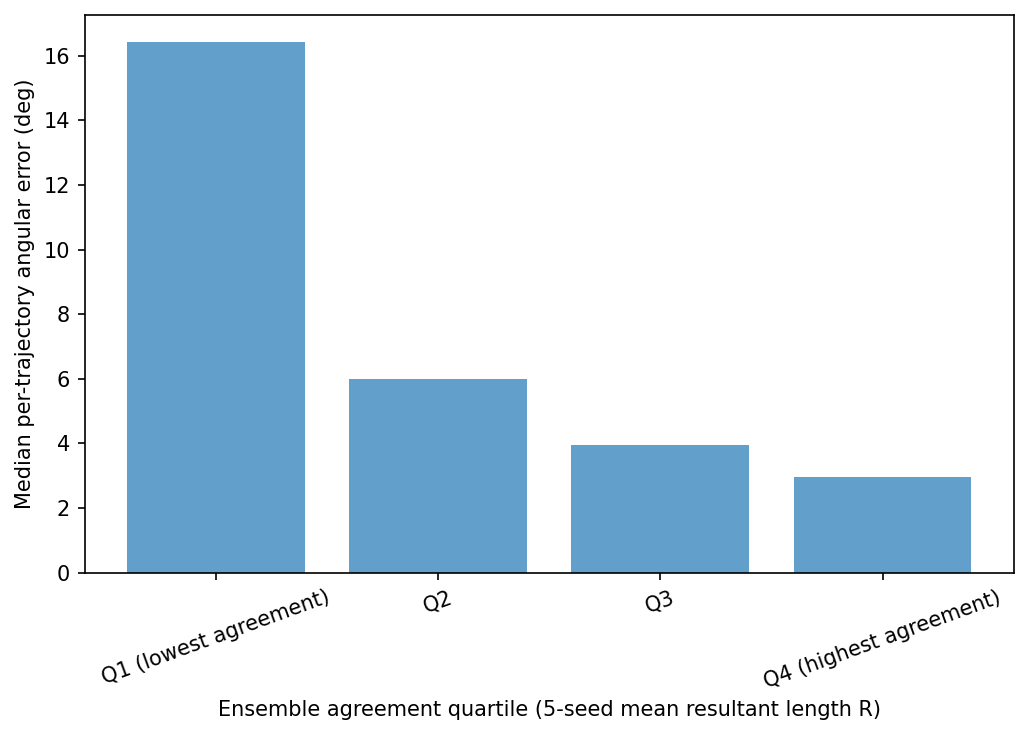

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.bar(calib_table['quartile'].astype(str), calib_table['median_err'], color='tab:blue', alpha=0.7)
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_xlabel('Ensemble agreement quartile (5-seed mean resultant length R)')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/ensemble_agreement_calibration.svg', format='svg', bbox_inches='tight')
plt.show()


**Significance:** Ensemble disagreement is a real, usable confidence signal, and a stronger one than in the original configuration (Spearman rho=-0.53 between agreement and error, up from -0.43, n=1099). Trajectories in the lowest agreement quartile have a median error of 16.4 deg -- more than 5x the median error of the highest-agreement quartile (3.0 deg, vs. roughly 3x before). In practice this means: for any new trajectory, running all 5 saved ensemble models (`../models/ensemble/ann_seed_*.keras`) and checking how tightly their predicted headings cluster gives a per-trajectory (or even per-frame) reliability estimate *without* needing ground truth. This is not a perfect predictor (rho=-0.53, not -1.0), so it should be read as a screening tool -- flagging trajectories for manual review or exclusion from high-stakes downstream analysis -- rather than a hard reliability guarantee. It is also worth noting that this signal captures within-distribution ambiguity, not out-of-distribution extrapolation: the leave-one-wind-out failure above (0.6 m/s upwind) is a case where the ensemble members, all trained on the same 0.3/0.4 m/s data, could plausibly agree with each other while still being collectively wrong -- which is exactly why the input-range check below is a necessary complement, not a redundant one.

#### Out-of-Range Input Warnings

As a minimum bar, `utils.check_inputs_in_training_range` checks new magnitude-type inputs
(groundspeed, airspeed; thrust if used) against the range actually observed in training and
prints a warning for any row that falls outside it. This is deliberately simple -- a bounding
box on the raw feature ranges, not a density estimate -- but it directly satisfies the
reviewer's minimum request that "the software documentation should warn users when airspeed,
thrust, or other inputs fall outside the training range." Angular features (e.g.
`groundspeed_angle`) are circular and intentionally excluded, since every direction was
represented during training via the wind-rotation augmentation.

In [ ]:
from utils import check_inputs_in_training_range

training_ranges = {
    'groundspeed': (train_df['groundspeed'].min(), train_df['groundspeed'].max()),
    'airspeed': (train_df['airspeed'].min(), train_df['airspeed'].max()),
}
print("Training ranges:", {k: (round(v[0], 4), round(v[1], 4)) for k, v in training_ranges.items()})

# Demonstration on a synthetic batch: two in-range rows, two out-of-range rows.
demo_groundspeed = np.array([0.3, 0.9, 2.5, 0.0001])
demo_airspeed = np.array([0.4, 1.0, 0.5, 3.0])
_ = check_inputs_in_training_range(
    {'groundspeed': demo_groundspeed, 'airspeed': demo_airspeed},
    training_ranges,
)


Training ranges: {'groundspeed': (0.0, 1.3862), 'airspeed': (0.0021, 1.6812)}
  groundspeed: 1 row(s) out of range (training range [3.645e-05, 1.386])
  airspeed: 1 row(s) out of range (training range [0.002057, 1.681])


**Significance:** The training data spans groundspeed 0-1.39 m/s and airspeed 0.002-1.68 m/s;
any deployment on trajectories with substantially faster (or, for airspeed, near-zero) flight
should treat predictions as extrapolation. Combined with the ensemble-agreement signal above,
this gives two complementary ways to flag an unreliable prediction: `R` catches cases that are
*kinematically ambiguous* even within the training distribution (e.g. high slip angle at a
in-range airspeed), while `check_inputs_in_training_range` catches cases that are *outside the
training distribution entirely* (e.g. a much faster flight regime than 0.3-0.6 m/s wind, or
software applied to a different species/setup). Neither replaces validating against ground
truth where it is available, but both are usable at inference time when it is not.